# Clinically Aligned Arrhythmia Classification using Physiological Alignment Supervision
## CS437/CS5317/EE414/EE513: Deep Learning, Spring 2026
### Hassan Iftikhar (27100204) | Saim Bilal (27100208)

This notebook enhances a baseline raw-signal **1D ResNet** arrhythmia classifier on **PTB-XL** by introducing
**class-conditioned physiological supervision** — guiding the model's temporal evidence toward
physiologically meaningful ECG regions associated with each arrhythmia class.

### Scientific Objective
Not "the network reasons exactly like a cardiologist," but rather:

> *the optimization process is regularized toward physiologically meaningful ECG regions associated with each arrhythmia class.*

### Pipeline Overview
```
Raw ECG  →  z-score  →  ResNet1D  →  feature map  →  GAP  →  classifier  →  logits  →  BCE
                                          │
                                          └───→  Class-CAM  ──────┐
                                                                  │
                                                  Physio prior ───┼──→ KL alignment + outside-mass + entropy
                                                                  ↓
                                          L_total = L_cls + λ_align·L_align + λ_out·L_out + λ_ent·L_entropy
```

### Loss-Function Ablation (the only ablation in this notebook)

| Condition  | L_cls | L_align | L_out | L_entropy |
|------------|-------|---------|-------|-----------|
| Baseline   |   ✓   |    ✗    |   ✗   |     ✗     |
| Align      |   ✓   |    ✓    |   ✗   |     ✗     |
| Align+Out  |   ✓   |    ✓    |   ✓   |     ✗     |
| Full       |   ✓   |    ✓    |   ✓   |     ✓     |

All experiments use **identical raw + z-score preprocessing**. Differences come entirely from the loss.

### Metrics
- **Classification**: Macro-AUROC, Macro-F1, per-class AUC
- **Localization**: Mean Alignment Score (MAS) on Grad-CAM vs delineation-derived ECG mask


## 1. Imports and Reproducibility

In [3]:
import ast
import os
import copy
import time
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import neurokit2 as nk
import torch
import torch.nn as nn
import torch.nn.functional as F
import wfdb
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, f1_score
try:
    from IPython.display import display
except Exception:
    def display(x):
        try:
            print(x.to_string() if hasattr(x, "to_string") else x)
        except Exception:
            print(x)

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable=None, **kwargs):
        return iterable if iterable is not None else iter([])

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Numerical stability constant
EPS = 1e-8

print(f"NeuroKit2 : {nk.__version__}")
print(f"PyTorch   : {torch.__version__}")
print(f"CUDA avail: {torch.cuda.is_available()}")
print("Imports ready.")


NeuroKit2 : 0.2.13
PyTorch   : 2.10.0+cu128
CUDA avail: True
Imports ready.


## 2. Configuration

In [4]:
# ── Paths ────────────────────────────────────────────────────────────────────
DATA_PATH = "/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/"
SAVE_PATH = "/kaggle/working/"
# DATA_PATH = "/mnt/d/lums_nerd_stuff/jnr_spring/CS437/project/ptb-xl/"
# SAVE_PATH = "/mnt/d/lums_nerd_stuff/jnr_spring/CS437/project/final_improv/save_path/"
os.makedirs(SAVE_PATH, exist_ok=True)

# ── Signal / lead config ─────────────────────────────────────────────────────
FS         = 500            # PTB-XL high-resolution sampling frequency
SIGNAL_LEN = 5000           # 10-second window at 500 Hz
LEAD_INDICES = [0, 1, 6]    # Leads I, II, V1
LEAD_NAMES   = ['I', 'II', 'V1']
N_LEADS      = len(LEAD_INDICES)
MORPH_LEAD   = 1            # Lead II — used for R-peak detection / delineation

# ── Labels ───────────────────────────────────────────────────────────────────
SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
N_CLASSES    = len(SUPERCLASSES)

# ── Single preprocessing condition: raw + z-score (per implementation plan) ─
RAW_CONDITION_NAME = 'raw_zscore'
ALIGNED_CONDITION  = RAW_CONDITION_NAME

# ── Training hyper-parameters ────────────────────────────────────────────────
TRAIN_BATCH_SIZE  = 64
TRAIN_LR          = 1e-3
TRAIN_WEIGHT_DECAY = 1e-4
TRAIN_LR_FACTOR   = 0.1
TRAIN_LR_PATIENCE = 4
PRED_THRESHOLD    = 0.5
MAX_MAS_SAMPLES   = 256

# ── Physiological alignment hyper-parameters ─────────────────────────────────
TORCH_SEED_ALIGNED = 42

ALIGN_CFG = {
    "ALIGN_WARMUP_EPOCHS": 5,    # epochs with alignment losses disabled
    "LAMBDA_ALIGN_MAX":    0.10, # max KL-divergence alignment weight
    "LAMBDA_OUT_MAX":      0.05, # max outside-mass penalty weight
    "LAMBDA_ENT_MAX":      0.005,# max entropy sharpness weight
    "NUM_EPOCHS_ALIGNED":  30,   # training epochs per ablation
    "PATIENCE_ALIGNED":    7,    # early-stopping patience
    "GRAD_CLIP_NORM":      5.0,  # gradient clip norm
}

# Physiological timing offsets relative to R-peak (milliseconds)
PHYSIO_TIMINGS_MS = {
    "p_offset_ms":    -160, "p_sigma_ms":    60,
    "qrs_offset_ms":     0, "qrs_sigma_ms":  40,
    "t_offset_ms":     280, "t_sigma_ms":   100,
    "st_offset_ms":    120, "st_sigma_ms":   60,
}

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Sanity checks
assert os.path.exists(DATA_PATH + "ptbxl_database.csv"), "ptbxl_database.csv not found"
assert os.path.exists(DATA_PATH + "scp_statements.csv"), "scp_statements.csv not found"
assert os.path.exists(DATA_PATH + "records500/"),       "records500/ not found"

print(f"Device     : {DEVICE}")
print(f"Leads      : {LEAD_NAMES} | Signal: {SIGNAL_LEN} samples @ {FS} Hz")
print(f"Superclasses: {SUPERCLASSES}")
print(f"Condition  : {RAW_CONDITION_NAME}  (single — raw + z-score only)")
print(f"Training   : {ALIGN_CFG['NUM_EPOCHS_ALIGNED']} epochs, batch {TRAIN_BATCH_SIZE}, lr {TRAIN_LR}")


Device     : cuda
Leads      : ['I', 'II', 'V1'] | Signal: 5000 samples @ 500 Hz
Superclasses: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
Condition  : raw_zscore  (single — raw + z-score only)
Training   : 30 epochs, batch 64, lr 0.001


## 3. Metadata, Labels, and Splits

In [5]:
# Load PTB-XL metadata + diagnostic SCP statements, derive 5-class superclass labels,
# and create train/val/test splits by stratified fold (PTB-XL convention).

df = pd.read_csv(DATA_PATH + "ptbxl_database.csv", index_col="ecg_id")
scp_df = pd.read_csv(DATA_PATH + "scp_statements.csv", index_col=0)
scp_df = scp_df[scp_df.diagnostic == 1]

df['scp_codes'] = df['scp_codes'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)


def get_superclass(scp_codes):
    out = []
    for code, likelihood in scp_codes.items():
        if code in scp_df.index:
            sc = scp_df.loc[code, 'diagnostic_class']
            if pd.notna(sc) and likelihood > 0:
                out.append(sc)
    return list(set(out))


df['superclass'] = df['scp_codes'].apply(get_superclass)
df_filtered = df[df['superclass'].map(len) > 0].copy()

# Multi-label one-hot encoding
for cls in SUPERCLASSES:
    df_filtered[cls] = df_filtered['superclass'].apply(lambda x: int(cls in x))

# Standard PTB-XL split: folds 1–8 train, fold 9 val, fold 10 test
train_df = df_filtered[df_filtered['strat_fold'] <= 8].copy()
val_df   = df_filtered[df_filtered['strat_fold'] == 9].copy()
test_df  = df_filtered[df_filtered['strat_fold'] == 10].copy()

train_pids = set(train_df['patient_id'].unique())
test_pids  = set(test_df['patient_id'].unique())
overlap    = train_pids & test_pids

print(f"Total labelled records : {len(df_filtered):,}")
print(f"Train/Val/Test         : {len(train_df):,} / {len(val_df):,} / {len(test_df):,}")
print(f"Patient overlap (train ∩ test): {len(overlap)}  →  {'OK' if not overlap else '⚠ shared patients!'}")


Total labelled records : 21,417
Train/Val/Test         : 17,100 / 2,155 / 2,162
Patient overlap (train ∩ test): 0  →  OK


### 3.1 Class Distribution

Class Distribution (full labelled dataset):
----------------------------------------
  NORM  :  9,528 (44.5%)
  MI    :  5,486 (25.6%)
  STTC  :  5,123 (23.9%)
  CD    :  4,907 (22.9%)
  HYP   :  2,655 (12.4%)


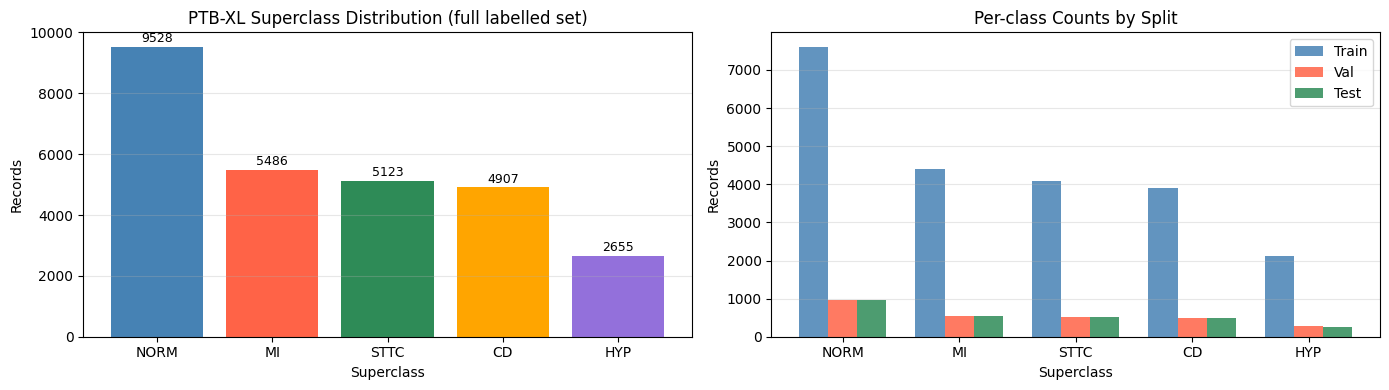

In [6]:
# Per-superclass record counts and per-split distribution.
all_labels = [lbl for sub in df_filtered['superclass'] for lbl in sub]
label_counts = Counter(all_labels)

print("Class Distribution (full labelled dataset):")
print("-" * 40)
for cls in SUPERCLASSES:
    cnt = label_counts.get(cls, 0)
    pct = cnt / len(df_filtered) * 100
    print(f"  {cls:<6}: {cnt:>6,} ({pct:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overall distribution
colors = ['steelblue', 'tomato', 'seagreen', 'orange', 'mediumpurple']
counts_ordered = [label_counts.get(c, 0) for c in SUPERCLASSES]
bars = axes[0].bar(SUPERCLASSES, counts_ordered, color=colors)
for bar, cnt in zip(bars, counts_ordered):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(cnt), ha='center', va='bottom', fontsize=9)
axes[0].set_title("PTB-XL Superclass Distribution (full labelled set)")
axes[0].set_xlabel("Superclass"); axes[0].set_ylabel("Records")
axes[0].grid(True, axis='y', alpha=0.3)

# Per-split grouped bars
width = 0.25
x = list(range(len(SUPERCLASSES)))
for split_df, label, color, offset in [
    (train_df, 'Train', 'steelblue', -width),
    (val_df,   'Val',   'tomato',     0),
    (test_df,  'Test',  'seagreen',   width),
]:
    counts = [int(split_df[c].sum()) for c in SUPERCLASSES]
    axes[1].bar([xi + offset for xi in x], counts, width=width,
                label=label, color=color, alpha=0.85)
axes[1].set_title("Per-class Counts by Split")
axes[1].set_xlabel("Superclass"); axes[1].set_ylabel("Records")
axes[1].set_xticks(x); axes[1].set_xticklabels(SUPERCLASSES)
axes[1].legend(); axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Raw ECG Loading & Preprocessing (z-score only)

Per the implementation plan, the preprocessing ablation already established that
**raw ECG with z-score normalization preserves clinically useful morphology best**.
This notebook therefore uses *only* z-score normalization — no Butterworth, no SWT, no augmentation.


In [7]:
# z-score per-lead → preserves shape, removes amplitude offset, no morphology distortion.

def zscore(signal_1d):
    return (signal_1d - signal_1d.mean()) / (signal_1d.std() + EPS)


def load_record(row):
    """Load 12-lead WFDB record and return only the chosen 3 leads as float32."""
    record = wfdb.rdrecord(DATA_PATH + row['filename_hr'])
    return record.p_signal[:, LEAD_INDICES].T.astype(np.float32)   # [3, SIGNAL_LEN]


def preprocess_raw_zscore(row):
    """Load record + z-score per lead. The ONLY preprocessing in this notebook."""
    raw = load_record(row)
    out = np.empty_like(raw, dtype=np.float32)
    for i in range(N_LEADS):
        out[i] = zscore(raw[i]).astype(np.float32)
    return out


def get_label(row):
    return np.array([row[c] for c in SUPERCLASSES], dtype=np.float32)


print("Raw + z-score preprocessing ready.")


Raw + z-score preprocessing ready.


### 4.1 R-Peak Detection & Delineation Utilities

These utilities are used for **two purposes**:
  1. Build the **binary P/QRS/T mask** stored alongside each sample for **MAS evaluation only**.
  2. Detect R-peaks during **alignment-mask pre-computation** (Section 9d) for the soft Gaussian priors.

NeuroKit2 is used for clean → R-peak detection → DWT-based delineation.
Multi-lead majority voting reduces R-peak miss rate.


In [8]:
# R-peak / delineation helpers (reused from baseline; preprocessing variants removed).

PEAK_VOTE_TOL_MS    = 80    # tolerance (ms) for majority-vote R-peak agreement
PEAK_VOTE_MIN_LEADS = 2     # minimum number of leads agreeing


def clean_peak_array(peaks, signal_len=SIGNAL_LEN):
    if peaks is None:
        return np.array([], dtype=int)
    arr = np.asarray(peaks, dtype=float).reshape(-1)
    arr = arr[np.isfinite(arr)]
    arr = arr[(arr >= 0) & (arr < signal_len)]
    if arr.size == 0:
        return np.array([], dtype=int)
    return np.unique(arr.astype(int))


def detect_r_peaks_1lead(signal_1d):
    """Single-lead R-peak detection via NeuroKit2."""
    try:
        cleaned = nk.ecg_clean(signal_1d, sampling_rate=FS)
        _, info = nk.ecg_peaks(cleaned, sampling_rate=FS)
        return clean_peak_array(info.get('ECG_R_Peaks', []), signal_len=len(signal_1d))
    except Exception:
        return np.array([], dtype=int)


def vote_r_peaks_multilead(signal_3lead, tol_ms=PEAK_VOTE_TOL_MS, min_votes=PEAK_VOTE_MIN_LEADS):
    """Majority-vote R-peak detection across 3 leads. Falls back to MORPH_LEAD if no consensus."""
    tol = max(1, int(round(tol_ms * FS / 1000.0)))
    lead_peaks = [detect_r_peaks_1lead(signal_3lead[i]) for i in range(signal_3lead.shape[0])]

    pooled = []
    for lead_id, peaks in enumerate(lead_peaks):
        for p in peaks:
            pooled.append((int(p), lead_id))
    if not pooled:
        return np.array([], dtype=int)

    pooled.sort(key=lambda x: x[0])
    clusters, cur = [], [pooled[0]]
    for peak, lead_id in pooled[1:]:
        if peak - cur[-1][0] <= tol:
            cur.append((peak, lead_id))
        else:
            clusters.append(cur); cur = [(peak, lead_id)]
    clusters.append(cur)

    voted = []
    for cl in clusters:
        if len({lead for _, lead in cl}) >= min_votes:
            voted.append(int(round(np.median([p for p, _ in cl]))))

    if not voted:
        voted = detect_r_peaks_1lead(signal_3lead[MORPH_LEAD]).tolist()

    voted = np.array(sorted(voted), dtype=int)
    if voted.size <= 1:
        return voted

    # Merge any near-duplicates that survived the cluster step
    merged = [int(voted[0])]
    for p in voted[1:]:
        if p - merged[-1] <= tol:
            merged[-1] = int(round((merged[-1] + p) / 2.0))
        else:
            merged.append(int(p))
    return np.array(merged, dtype=int)


def _safe_index(v, signal_len):
    try:
        if v is None:
            return None
        x = float(v)
        if np.isnan(x):
            return None
        i = int(round(x))
        if i < 0 or i >= signal_len:
            return None
        return i
    except Exception:
        return None


def _fill_mask_from_pairs(mask, onsets, offsets, centers=None, half_width=10):
    n = max(len(onsets), len(offsets), len(centers) if centers is not None else 0)
    for i in range(n):
        on  = _safe_index(onsets[i],  len(mask)) if i < len(onsets)  else None
        off = _safe_index(offsets[i], len(mask)) if i < len(offsets) else None
        center = _safe_index(centers[i], len(mask)) if (centers is not None and i < len(centers)) else None
        if on is None and center is not None:
            on = center - half_width
        if off is None and center is not None:
            off = center + half_width
        if on is None or off is None:
            continue
        lo = max(0, min(on, off))
        hi = min(len(mask) - 1, max(on, off))
        mask[lo:hi + 1] = True


def extract_boundaries_multilead(signal_3lead):
    """DWT-based delineation on the morphology lead, using majority-voted R-peaks."""
    lead_signal = signal_3lead[MORPH_LEAD]
    cleaned = nk.ecg_clean(lead_signal, sampling_rate=FS)

    voted_peaks = vote_r_peaks_multilead(signal_3lead)
    if len(voted_peaks) == 0:
        voted_peaks = detect_r_peaks_1lead(lead_signal)
    if len(voted_peaks) == 0:
        return None

    try:
        _, waves = nk.ecg_delineate(cleaned, voted_peaks, sampling_rate=FS, method='dwt')
    except Exception:
        return None

    return {
        'r_peaks':     np.array(voted_peaks, dtype=int),
        'p_onsets':    np.asarray(waves.get('ECG_P_Onsets',   []), dtype=float),
        'p_offsets':   np.asarray(waves.get('ECG_P_Offsets',  []), dtype=float),
        'qrs_onsets':  np.asarray(waves.get('ECG_R_Onsets',   []), dtype=float),
        'qrs_offsets': np.asarray(waves.get('ECG_R_Offsets',  []), dtype=float),
        't_onsets':    np.asarray(waves.get('ECG_T_Onsets',   []), dtype=float),
        't_offsets':   np.asarray(waves.get('ECG_T_Offsets',  []), dtype=float),
    }


def build_binary_mask_from_boundaries(boundaries, signal_len=SIGNAL_LEN):
    """Binary 1-D mask: 1 on P/QRS/T regions, 0 elsewhere. For MAS evaluation only."""
    mask = np.zeros(signal_len, dtype=np.float32)
    if boundaries is None:
        return mask
    r = boundaries['r_peaks']
    _fill_mask_from_pairs(mask, boundaries['p_onsets'],   boundaries['p_offsets'],
                          centers=r, half_width=int(0.04 * FS))
    _fill_mask_from_pairs(mask, boundaries['qrs_onsets'], boundaries['qrs_offsets'],
                          centers=r, half_width=int(0.02 * FS))
    _fill_mask_from_pairs(mask, boundaries['t_onsets'],   boundaries['t_offsets'],
                          centers=r, half_width=int(0.08 * FS))
    return mask


def build_mask_for_record(signal_3lead):
    """Convenience: extract boundaries → binary mask. Returns (mask, boundaries)."""
    boundaries = extract_boundaries_multilead(signal_3lead)
    mask = build_binary_mask_from_boundaries(boundaries, signal_len=signal_3lead.shape[1])
    return mask, boundaries


print("R-peak / delineation utilities ready.")


R-peak / delineation utilities ready.


## 5. Build and Save the Dataset

In [9]:
# Build raw + z-score dataset for the single condition '{cond}'.
# Uses a parallel record-level cache (.npz per ecg_id) so re-runs are fast.

from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp

CACHE_VERSION = 'raw_zscore_v1'
CACHE_ROOT    = os.path.join(SAVE_PATH, '_record_cache', CACHE_VERSION)
DATASET_BUILD_WORKERS = 4
DATASET_POOL_CHUNK    = 16
CACHE_PROGRESS_EVERY  = 500
os.makedirs(CACHE_ROOT, exist_ok=True)


def _cache_path_for(ecg_id, create_dirs=False):
    bucket = f"{(int(ecg_id) // 1000) * 1000:05d}"
    cache_dir = os.path.join(CACHE_ROOT, bucket)
    if create_dirs:
        os.makedirs(cache_dir, exist_ok=True)
    return os.path.join(cache_dir, f"{int(ecg_id):05d}.npz")


def _row_to_task(row_idx, row):
    return {
        'ecg_id':      int(row_idx),
        'filename_hr': row['filename_hr'],
        'y':           np.array([row[c] for c in SUPERCLASSES], dtype=np.float32),
    }


def _compute_cached_record_worker(task):
    cache_path = _cache_path_for(task['ecg_id'], create_dirs=True)
    if os.path.exists(cache_path):
        return True, task['ecg_id'], 'hit', ''
    tmp_path = cache_path + f".tmp.{os.getpid()}.npz"
    try:
        x = preprocess_raw_zscore({'filename_hr': task['filename_hr']})
        mask, _ = build_mask_for_record(x)
        np.savez(tmp_path, X=x.astype(np.float32), M=mask.astype(np.float32))
        os.replace(tmp_path, cache_path)
        return True, task['ecg_id'], 'miss', ''
    except Exception as exc:
        try:
            if os.path.exists(tmp_path):
                os.remove(tmp_path)
        except Exception:
            pass
        return False, task['ecg_id'], 'error', repr(exc)


def _ensure_cache(tasks, split_name):
    missing = [t for t in tasks
               if not os.path.exists(_cache_path_for(t['ecg_id'], create_dirs=False))]
    total = len(tasks)
    if not missing:
        print(f"  Cache ready for {split_name}: 100% hit ({total}/{total})")
        return

    n_workers = min(DATASET_BUILD_WORKERS, len(missing))
    print(f"  Caching {split_name}: missing={len(missing)}/{total} | workers={n_workers}")

    built, failed = 0, 0
    sample_errors = []

    def _record(result):
        nonlocal built, failed
        ok, _, state, err = result
        if ok and state == 'miss':
            built += 1
        elif not ok:
            failed += 1
            if len(sample_errors) < 5:
                sample_errors.append(err)

    if n_workers <= 1:
        for i, t in enumerate(missing, 1):
            _record(_compute_cached_record_worker(t))
            if i % CACHE_PROGRESS_EVERY == 0 or i == len(missing):
                print(f"    progress {i}/{len(missing)} | built={built} failed={failed}", end='\r')
        print()
    else:
        try:
            ctx = mp.get_context('fork')
            with ProcessPoolExecutor(max_workers=n_workers, mp_context=ctx) as ex:
                for i, result in enumerate(
                    ex.map(_compute_cached_record_worker, missing,
                           chunksize=DATASET_POOL_CHUNK), 1):
                    _record(result)
                    if i % CACHE_PROGRESS_EVERY == 0 or i == len(missing):
                        print(f"    progress {i}/{len(missing)} | built={built} failed={failed}", end='\r')
                print()
        except Exception as exc:
            print(f"    multiprocessing failed ({exc}); using serial fallback.")
            for i, t in enumerate(missing, 1):
                _record(_compute_cached_record_worker(t))
                if i % CACHE_PROGRESS_EVERY == 0 or i == len(missing):
                    print(f"    progress {i}/{len(missing)} | built={built} failed={failed}", end='\r')
            print()

    print(f"  Cache summary {split_name}: built={built} failed={failed}")
    if sample_errors:
        print("  Sample errors:")
        for e in sample_errors:
            print(f"    - {e}")


def _load_cached(task):
    with np.load(_cache_path_for(task['ecg_id'])) as data:
        x = data['X'].astype(np.float32, copy=False)
        m = data['M'].astype(np.float32, copy=False)
    return x, m


def build_dataset(df_split, split_name):
    tasks = [_row_to_task(idx, row) for idx, row in df_split.iterrows()]
    print(f"  Building {split_name}: {len(tasks)} records")
    _ensure_cache(tasks, split_name)

    X_list, y_list, m_list = [], [], []
    failed = 0
    for i, task in enumerate(tasks):
        if i % 500 == 0:
            print(f"    assembling {i}/{len(tasks)}", end='\r')
        try:
            x, m = _load_cached(task)
            X_list.append(x); y_list.append(task['y']); m_list.append(m)
        except Exception:
            failed += 1
    print()

    X = np.stack(X_list, axis=0).astype(np.float32)
    y = np.stack(y_list, axis=0).astype(np.float32)
    M = np.stack(m_list, axis=0).astype(np.float32)
    print(f"    Done: X={X.shape}, y={y.shape}, M={M.shape}, failed={failed}")
    print(f"    Mean mask coverage = {M.mean()*100:.2f}%")
    return X, y, M


def save_split(df_split, split_path, split_name, force_rebuild=False):
    if (not force_rebuild) and os.path.exists(split_path):
        print(f"  Reuse existing split: {split_name}")
        return
    X, y, M = build_dataset(df_split, split_name)
    torch.save({
        'X':    torch.from_numpy(X),
        'y':    torch.from_numpy(y),
        'M':    torch.from_numpy(M),
        'meta': {
            'condition':       RAW_CONDITION_NAME,
            'superclasses':    SUPERCLASSES,
            'lead_names':      LEAD_NAMES,
            'signal_len':      SIGNAL_LEN,
            'morph_lead':      MORPH_LEAD,
            'preprocessing':   'raw + z-score per lead',
            'mask_definition': 'binary; 1 on P/QRS/T regions, 0 elsewhere (for MAS only)',
        },
    }, split_path)
    print(f"  Saved → {split_path}")


# ── Build & save the single condition ───────────────────────────────────────
FORCE_REBUILD_DATASETS = False

condition_dir = os.path.join(SAVE_PATH, RAW_CONDITION_NAME)
os.makedirs(condition_dir, exist_ok=True)

print(f"== Building dataset for condition: {RAW_CONDITION_NAME} ==")
save_split(train_df, os.path.join(condition_dir, 'train.pt'), 'train',
           force_rebuild=FORCE_REBUILD_DATASETS)
save_split(val_df,   os.path.join(condition_dir, 'val.pt'),   'val',
           force_rebuild=FORCE_REBUILD_DATASETS)
save_split(test_df,  os.path.join(condition_dir, 'test.pt'),  'test',
           force_rebuild=FORCE_REBUILD_DATASETS)

# Verify shapes
print()
print("=== Tensor shapes ===")
for split in ['train', 'val', 'test']:
    data = torch.load(os.path.join(condition_dir, f'{split}.pt'), map_location='cpu')
    print(f"  {split:5s}: X={tuple(data['X'].shape)}  y={tuple(data['y'].shape)}  M={tuple(data['M'].shape)}")

print('\nDataset ready.')


== Building dataset for condition: raw_zscore ==
  Building train: 17100 records
  Caching train: missing=17100/17100 | workers=4
    progress 17100/17100 | built=17100 failed=0
  Cache summary train: built=17100 failed=0
    assembling 17000/17100
    Done: X=(17100, 3, 5000), y=(17100, 5), M=(17100, 5000), failed=0
    Mean mask coverage = 45.11%
  Saved → /kaggle/working/raw_zscore/train.pt
  Building val: 2155 records
  Caching val: missing=2155/2155 | workers=4
    progress 2155/2155 | built=2155 failed=0
  Cache summary val: built=2155 failed=0
    assembling 2000/2155
    Done: X=(2155, 3, 5000), y=(2155, 5), M=(2155, 5000), failed=0
    Mean mask coverage = 44.90%
  Saved → /kaggle/working/raw_zscore/val.pt
  Building test: 2162 records
  Caching test: missing=2162/2162 | workers=4
    progress 2162/2162 | built=2162 failed=0
  Cache summary test: built=2162 failed=0
    assembling 2000/2162
    Done: X=(2162, 3, 5000), y=(2162, 5), M=(2162, 5000), failed=0
    Mean mask covera

## 6. Model — Feature-Exposing 1D ResNet

The architecture is the **baseline 1D ResNet** with a **single addition**: `forward(x, return_features=True)`
exposes the pre-GAP feature map `[B, 256, T_feat]`.  This map is required for class-specific CAM computation
during alignment training.  The classifier head, residual blocks, kernel sizes, channel counts, and skip
connections are unchanged.


In [10]:
# -----------------------------------------------------------------------------
# 1D-ResNet architecture — feature-exposing version (Stage 3 update)
# Backward-compatible: forward(x) still works; forward(x, return_features=True)
# additionally returns the pre-GAP feature map used for CAM supervision.
# -----------------------------------------------------------------------------
import torch.nn as nn
import torch.nn.functional as F

class ResBlock1D(nn.Module):
    """Basic 1D residual block with optional stride downsampling."""

    def __init__(self, in_ch, out_ch, stride=1, kernel_size=7):
        super().__init__()
        pad = kernel_size // 2

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride, padding=pad, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, stride=1, padding=pad, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.dropout = nn.Dropout(0.2)

        self.skip = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.dropout(out)
        return F.relu(out + self.skip(x))


class ResNet1D(nn.Module):
    """
    Baseline-compatible 1D-ResNet for multi-label ECG classification.

    Stage 3 addition: return_features flag exposes the final convolutional
    feature map [B, 256, T_feat] immediately before global average pooling.
    This is required for class-specific CAM computation.
    """

    def __init__(self, n_leads=N_LEADS, n_classes=N_CLASSES):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(n_leads, 32, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
        )
        self.stage1 = self._make_stage(32,  32,  2, stride=1, kernel_size=15)
        self.stage2 = self._make_stage(32,  64,  2, stride=2, kernel_size=15)
        self.stage3 = self._make_stage(64,  128, 2, stride=2, kernel_size=7)
        self.stage4 = self._make_stage(128, 256, 2, stride=2, kernel_size=7)
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(256, n_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    @staticmethod
    def _make_stage(in_ch, out_ch, n_blocks, stride, kernel_size):
        layers = [ResBlock1D(in_ch, out_ch, stride, kernel_size)]
        for _ in range(1, n_blocks):
            layers.append(ResBlock1D(out_ch, out_ch, 1, kernel_size))
        return nn.Sequential(*layers)

    def forward(self, x, return_features=False):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)              # [B, 256, T_feat]
        features = x
        x = self.gap(x).squeeze(-1)     # [B, 256]
        logits = self.head(x)            # [B, N_CLASSES]
        if return_features:
            return logits, features
        return logits

    def get_gradcam_target_layer(self):
        """Last conv before GAP — used by GradCAM1D."""
        return self.stage4[-1].conv2


# ── Sanity check + T_FEAT probe ──────────────────────────────────────────────
_probe = ResNet1D().to(DEVICE)
with torch.no_grad():
    _dummy = torch.zeros(2, N_LEADS, SIGNAL_LEN, device=DEVICE)
    _logits, _feats = _probe(_dummy, return_features=True)
    T_FEAT = _feats.shape[-1]
    print(f"ResNet1D forward check  — logits: {tuple(_logits.shape)}, features: {tuple(_feats.shape)}")
    print(f"Feature map temporal length  T_FEAT = {T_FEAT}")
del _probe, _dummy, _logits, _feats


ResNet1D forward check  — logits: (2, 5), features: (2, 256, 313)
Feature map temporal length  T_FEAT = 313


## 7. Grad-CAM — Evaluation Only

Grad-CAM is used **only for visualization and MAS evaluation**, never as part of the training loss.
The training-time class activation maps (Section 9a) are derived directly from the classifier weights
× pre-GAP features and are far cheaper to compute.


In [11]:
class GradCAM1D:
    """Gradient-weighted Class Activation Mapping for 1D-ResNet (post-hoc only)."""

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.layer_activations = None
        self.layer_gradients = None
        self.fwd_hook = target_layer.register_forward_hook(self.save_activations)
        self.bwd_hook = target_layer.register_full_backward_hook(self.save_gradients)

    def save_activations(self, *args):
        self.layer_activations = args[2].detach()

    def save_gradients(self, *args):
        self.layer_gradients = args[2][0].detach()

    def remove_hooks(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()

    def compute(self, input_tensor, class_idx, output_length=SIGNAL_LEN):
        self.model.eval()
        inp = input_tensor.clone().requires_grad_(True)
        logits = self.model(inp)
        self.model.zero_grad()
        logits[0, class_idx].backward()

        weights = self.layer_gradients.mean(dim=-1).squeeze()
        act     = self.layer_activations.squeeze()
        cam     = F.relu((weights[:, None] * act).sum(dim=0))

        cam_np = cam.detach().cpu().numpy()
        cam_up = np.interp(
            np.linspace(0, len(cam_np) - 1, output_length),
            np.arange(len(cam_np)),
            cam_np,
        )
        if cam_up.max() > 1e-10:
            cam_up = cam_up / cam_up.max()
        return cam_up.astype(np.float32)


def compute_mas_from_gradcam(gradcam_1d, mask_1d, output_len=SIGNAL_LEN):
    """
    Mean Alignment Score:
        MAS = sum(heat * mask) / sum(heat)
    Range [0, 1]; higher = more attention concentrated on physiological regions.
    """
    heat = np.asarray(gradcam_1d, dtype=np.float32).reshape(-1)
    mask = np.asarray(mask_1d,    dtype=np.float32).reshape(-1)

    if len(mask) != output_len:
        raise ValueError(f"mask length must be {output_len}, got {len(mask)}")
    if len(heat) != output_len:
        x_old = np.linspace(0.0, 1.0, len(heat))
        x_new = np.linspace(0.0, 1.0, output_len)
        heat  = np.interp(x_new, x_old, heat).astype(np.float32)

    heat = np.maximum(heat, 0.0)
    denom = float(heat.sum())
    if denom <= 1e-10:
        return 0.0
    return float((heat * mask).sum() / denom)


print("Grad-CAM utilities ready.")


Grad-CAM utilities ready.


## 8. Training & Evaluation Utilities

In [12]:
# Shared training utilities (dataset class, loss helpers, eval, MAS).

class ECGTensorDataset(Dataset):
    """Tensor-backed dataset returning (X, y, M) per item."""

    def __init__(self, X, y, M):
        self.X = X.float()
        self.y = y.float()
        self.M = M.float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.M[idx]


def load_condition_split(condition_name, split_name):
    """Load (X, y, M) tensors for a saved split."""
    path = os.path.join(SAVE_PATH, condition_name, f"{split_name}.pt")
    data = torch.load(path, map_location='cpu')
    return data['X'].float(), data['y'].float(), data['M'].float()


def compute_pos_weight_from_y(y_tensor):
    """Per-class pos_weight for BCEWithLogitsLoss (handles class imbalance)."""
    n     = y_tensor.shape[0]
    n_pos = y_tensor.sum(dim=0)
    n_neg = n - n_pos
    return (n_neg / torch.clamp(n_pos, min=1.0)).float()


def macro_auc_safe(y_true, y_prob):
    try:
        return float(roc_auc_score(y_true, y_prob, average='macro', multi_class='ovr'))
    except ValueError:
        return float('nan')


def per_class_auc_safe(y_true, y_prob, class_names=SUPERCLASSES):
    out = {}
    for i, cls in enumerate(class_names):
        try:
            out[f"auc_{cls}"] = float(roc_auc_score(y_true[:, i], y_prob[:, i]))
        except ValueError:
            out[f"auc_{cls}"] = float('nan')
    return out


def evaluate_predictions(y_true, y_prob, threshold=PRED_THRESHOLD):
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        'test_macro_auc': macro_auc_safe(y_true, y_prob),
        'test_macro_f1':  float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
    }
    metrics.update(per_class_auc_safe(y_true, y_prob, SUPERCLASSES))
    return metrics


def compute_condition_mas(model, dataset, max_samples=MAX_MAS_SAMPLES):
    """
    CLASS-SPECIFIC Mean Alignment Score.

    For each sample, iterate over every ACTIVE class and compute GradCAM
    for that class against its class-specific physiological prior (from M_align).
    This is medically meaningful: CD should activate QRS, STTC should activate
    ST+T, etc. The combined score is the mean across (sample, active-class) pairs.

    Falls back to top-prob-class behaviour for ECGTensorDataset (no M_align).
    """
    if len(dataset) == 0:
        return float('nan'), float('nan')

    n = min(max_samples, len(dataset))
    rng = np.random.default_rng(SEED)
    idxs = rng.choice(len(dataset), size=n, replace=False) if n < len(dataset) else np.arange(len(dataset))

    gcam = GradCAM1D(model, model.get_gradcam_target_layer())
    mas_values = []

    for idx in idxs:
        item = dataset[int(idx)]

        # PhysioAlignedDataset → (X, y, M, M_align, conf)
        if len(item) == 5:
            x, y, _, M_align, _ = item
            active_classes = (y > 0.5).nonzero(as_tuple=True)[0].tolist()

            if not active_classes:
                continue

            x_inp = x.unsqueeze(0).to(DEVICE)

            for cls_idx in active_classes:
                # Class-specific prior at signal resolution (upsampled from T_feat)
                prior_feat = M_align[cls_idx].numpy()           # [T_feat]
                prior_sig  = np.interp(
                    np.linspace(0, 1, SIGNAL_LEN),
                    np.linspace(0, 1, len(prior_feat)),
                    prior_feat
                ).astype(np.float32)

                heat = gcam.compute(x_inp, cls_idx, output_length=SIGNAL_LEN)
                mas  = compute_mas_from_gradcam(heat, prior_sig, output_len=SIGNAL_LEN)
                mas_values.append(mas)

        else:
            # Fallback: ECGTensorDataset — use top-prob class + combined mask
            x, _, m = item[0], item[1], item[2]
            x_inp = x.unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                prob = torch.sigmoid(model(x_inp)).squeeze(0).cpu().numpy()
            cls_idx = int(np.argmax(prob))
            heat = gcam.compute(x_inp, cls_idx, output_length=SIGNAL_LEN)
            mas  = compute_mas_from_gradcam(heat, m.cpu().numpy(), output_len=SIGNAL_LEN)
            mas_values.append(mas)

    gcam.remove_hooks()

    if not mas_values:
        return float('nan'), float('nan')

    mas_arr = np.asarray(mas_values, dtype=np.float32)
    return float(np.mean(mas_arr)), float(np.std(mas_arr))


def compute_per_class_mas(model, dataset, max_samples=MAX_MAS_SAMPLES):
    """
    Returns a per-class MAS dict: {'mas_NORM': ..., 'mas_MI': ..., ...}
    and the global mean across classes.
    """
    if len(dataset) == 0:
        return {f'mas_{c}': float('nan') for c in SUPERCLASSES}

    n = min(max_samples, len(dataset))
    rng = np.random.default_rng(SEED)
    idxs = rng.choice(len(dataset), n, replace=False) if n < len(dataset) else np.arange(len(dataset))

    gcam = GradCAM1D(model, model.get_gradcam_target_layer())
    per_class = {cls: [] for cls in SUPERCLASSES}

    for idx in idxs:
        item = dataset[int(idx)]
        if len(item) != 5:
            continue
        x, y, _, M_align, _ = item
        active_classes = (y > 0.5).nonzero(as_tuple=True)[0].tolist()
        if not active_classes:
            continue
        x_inp = x.unsqueeze(0).to(DEVICE)

        for cls_idx in active_classes:
            prior_feat = M_align[cls_idx].numpy()
            prior_sig  = np.interp(
                np.linspace(0, 1, SIGNAL_LEN),
                np.linspace(0, 1, len(prior_feat)),
                prior_feat
            ).astype(np.float32)
            heat = gcam.compute(x_inp, cls_idx, output_length=SIGNAL_LEN)
            mas  = compute_mas_from_gradcam(heat, prior_sig, output_len=SIGNAL_LEN)
            per_class[SUPERCLASSES[cls_idx]].append(mas)

    gcam.remove_hooks()

    results = {}
    for cls, vals in per_class.items():
        results[f'mas_{cls}'] = float(np.nanmean(vals)) if vals else float('nan')
    results['mean_class_specific_mas'] = float(np.nanmean([v for v in results.values() if np.isfinite(v)]))
    return results

print("Training & evaluation utilities ready.")


Training & evaluation utilities ready.


## 9. Physiological Alignment Supervision Framework

### Scientific Motivation
A CNN trained with classification loss alone can achieve high AUROC while localising evidence
in non-physiological regions (dataset shortcuts, spurious correlations).  **High accuracy does
not imply clinically meaningful reasoning.**

### Proposed Solution — Class-Conditioned Physiological Alignment Supervision
The model is regularised toward physiologically meaningful ECG regions associated with each
arrhythmia class using a **four-term loss**:

```
L_total = L_cls
        + λ_align · conf · L_align    (KL toward physiological prior)
        + λ_out   · conf · L_out      (penalise evidence leakage outside prior)
        + λ_ent              · L_entropy  (encourage sharp temporal localisation)
```

All alignment terms are **training-only**.  Validation and test evaluation use the standard
classification head.  A **warmup period** keeps λ = 0 for the first few epochs while the early
CAMs stabilise; afterwards λ ramps linearly to its maximum.


### 9a. Class-Specific CAM Extraction

In [13]:
# -----------------------------------------------------------------------------
# Class-Specific CAM Extraction
#
# Given pre-GAP features  [B, C, T_feat]  and classifier weights [K, C],
# compute class-specific temporal attention maps: cam[b,k,t] = ReLU(W[k]·f[b,:,t])
# Then normalise each map to a probability distribution over time.
# -----------------------------------------------------------------------------

def compute_class_cam(features, classifier_weight, eps=1e-8):
    """
    Compute class-specific CAMs from pre-GAP feature maps.

    Args:
        features         : [B, C, T_feat]  — output of stage4 before GAP
        classifier_weight: [K, C]          — model.head.weight
        eps              : numerical stability constant

    Returns:
        cam: [B, K, T_feat] — normalised temporal probability distributions
             Values ≥ 0; sums to 1 across time for each (batch, class) pair.
    """
    # cam[b,k,t] = ReLU( Σ_c W[k,c] * features[b,c,t] )
    cam = torch.einsum('kc,bct->bkt', classifier_weight, features)   # [B, K, T]
    cam = F.relu(cam)
    # Normalise → temporal probability distribution
    cam = cam / (cam.sum(dim=-1, keepdim=True) + eps)
    return cam


def validate_cam(cam, eps=1e-4):
    """Quick sanity checks.  Returns True or raises AssertionError."""
    assert cam.min() >= -eps,                   "CAM contains negative values"
    assert not torch.isnan(cam).any(),          "CAM contains NaN"
    assert not torch.isinf(cam).any(),          "CAM contains Inf"
    sums = cam.sum(dim=-1)
    assert torch.allclose(sums, torch.ones_like(sums), atol=1e-3), \
        f"CAM not normalised; range of sums: [{sums.min():.4f}, {sums.max():.4f}]"
    return True


# ── Self-test ────────────────────────────────────────────────────────────────
_test_feats = torch.randn(4, 256, T_FEAT)
_test_W     = torch.randn(N_CLASSES, 256)
_cam = compute_class_cam(_test_feats, _test_W)
assert _cam.shape == (4, N_CLASSES, T_FEAT), f"Unexpected CAM shape: {_cam.shape}"
validate_cam(_cam)
print(f"CAM self-test passed  — shape {tuple(_cam.shape)}, "
      f"values ≥ 0: {(_cam >= 0).all()}, "
      f"sums to 1: {torch.allclose(_cam.sum(-1), torch.ones(4, N_CLASSES), atol=1e-3)}")
del _test_feats, _test_W, _cam


CAM self-test passed  — shape (4, 5, 313), values ≥ 0: True, sums to 1: True


### 9b. Gaussian Soft Mask Generation

In [14]:
# -----------------------------------------------------------------------------
# Gaussian Soft Mask Generation
#
# ECG wave masks are SOFT (Gaussian), never hard binary.  This prevents
# the alignment signal from being overly rigid and respects delineation noise.
#
# We use an R-peak-based fast approximation (R-peak detection only, not full
# NeuroKit2 delineation) which is ~20× faster and still physiologically sound.
# Typical physiological offsets from R-peak at 500 Hz:
#   P-wave  : R - 160 ms   σ = 60 ms
#   QRS     : R ± 0 ms     σ = 40 ms
#   ST      : R + 120 ms   σ = 60 ms
#   T-wave  : R + 280 ms   σ = 100 ms
# -----------------------------------------------------------------------------

def gaussian_mask(length, center, sigma, device='cpu'):
    """Soft 1-D Gaussian mask of shape [length], centered at `center`."""
    t = torch.arange(length, dtype=torch.float32, device=device)
    return torch.exp(-((t - center) ** 2) / (2.0 * sigma ** 2 + EPS))

def compute_adaptive_timings(r_peaks, fs=FS, base_timings=None):
    """
    Scale Gaussian sigma values based on the patient's actual median RR interval.
    Normal RR ≈ 800 ms (75 bpm). Tachycardic ECGs get tighter sigmas to
    prevent wave regions from overlapping adjacent beats.
    """
    if base_timings is None:
        base_timings = PHYSIO_TIMINGS_MS

    if len(r_peaks) < 2:
        return dict(base_timings)

    rr_ms = float(np.median(np.diff(r_peaks)) / fs * 1000)  # ms
    scale = np.clip(rr_ms / 800.0, 0.5, 1.5)               # cap at ±50% of nominal

    return {
        'p_offset_ms':   base_timings['p_offset_ms'],
        'p_sigma_ms':    base_timings['p_sigma_ms']   * scale,
        'qrs_offset_ms': base_timings['qrs_offset_ms'],
        'qrs_sigma_ms':  base_timings['qrs_sigma_ms'],         # QRS width is disease-driven, don't scale
        't_offset_ms':   base_timings['t_offset_ms']  * scale,
        't_sigma_ms':    base_timings['t_sigma_ms']   * scale,
        'st_offset_ms':  base_timings['st_offset_ms'] * scale,
        'st_sigma_ms':   base_timings['st_sigma_ms']  * scale,
    }


def build_wave_masks_from_rpeaks(r_peaks, signal_len, fs=FS,
                                  timings=None, device='cpu'):
    """
    Build four soft Gaussian masks (P, QRS, ST, T) using R-peak positions
    and ADAPTIVE physiological timing offsets (scaled to patient HR).
    """
    r = np.asarray(r_peaks, dtype=float)

    # ── Adaptive timings ──────────────────────────────────────────────────
    timings = compute_adaptive_timings(r, fs=fs, base_timings=timings)

    def ms2samp(ms):
        return ms * fs / 1000.0

    def build_superimposed(centers, sigma_ms):
        mask = torch.zeros(signal_len, dtype=torch.float32, device=device)
        sigma = ms2samp(sigma_ms)
        for c in centers:
            mask += gaussian_mask(signal_len, float(c), sigma, device=device)
        total = mask.sum()
        if total > EPS:
            return mask / total
        mid = signal_len / 2.0
        fb = gaussian_mask(signal_len, mid, signal_len * 0.15, device=device)
        return fb / (fb.sum() + EPS)

    if len(r) == 0:
        mid = signal_len / 2.0
        fb = gaussian_mask(signal_len, mid, signal_len * 0.15, device=device)
        fb = fb / (fb.sum() + EPS)
        return {'qrs': fb, 'p': fb, 't': fb, 'st': fb, 'confidence': 0.3}

    def valid_centers(offsets_ms):
        c = r + ms2samp(offsets_ms)
        return c[(c >= 0) & (c < signal_len)]

    qrs_c = valid_centers(timings['qrs_offset_ms'])
    p_c   = valid_centers(timings['p_offset_ms'])
    t_c   = valid_centers(timings['t_offset_ms'])
    st_c  = valid_centers(timings['st_offset_ms'])

    confidence = 0.9 if len(r) >= 5 else (0.7 if len(r) >= 2 else 0.5)

    return {
        'qrs':        build_superimposed(qrs_c if len(qrs_c) else r,
                                         timings['qrs_sigma_ms']),
        'p':          build_superimposed(p_c,  timings['p_sigma_ms']),
        't':          build_superimposed(t_c,  timings['t_sigma_ms']),
        'st':         build_superimposed(st_c, timings['st_sigma_ms']),
        'confidence': confidence,
    }


def downsample_mask(mask_1d, T_feat, device='cpu'):
    """
    Downsample a 1-D mask from signal resolution to feature-map resolution
    using bilinear (linear) interpolation, then renormalise.
    """
    m = mask_1d.to(device).view(1, 1, -1).float()
    m = F.interpolate(m, size=T_feat, mode='linear', align_corners=False)
    m = m.squeeze(0).squeeze(0)
    total = m.sum()
    return m / (total + EPS)


# ── Self-test ────────────────────────────────────────────────────────────────
_fake_rpeaks = np.arange(200, SIGNAL_LEN, 500)  # ~8 beats
_wm = build_wave_masks_from_rpeaks(_fake_rpeaks, SIGNAL_LEN, fs=FS)
for key in ('qrs', 'p', 't', 'st'):
    s = _wm[key].sum().item()
    assert abs(s - 1.0) < 1e-3, f"wave mask '{key}' sum = {s:.4f} (expected ~1.0)"
print(f"Wave mask self-test passed  — "
      f"confidence={_wm['confidence']:.2f}, "
      f"QRS peak at {_wm['qrs'].argmax().item()} (R≈{_fake_rpeaks[len(_fake_rpeaks)//2]})")
del _fake_rpeaks, _wm


Wave mask self-test passed  — confidence=0.90, QRS peak at 200 (R≈2700)


### 9c. Class-Conditioned Physiological Priors

In [15]:
# -----------------------------------------------------------------------------
# Class-Conditioned Physiological Priors
#
# PTB-XL is multi-label.  Each active class contributes its own physiological
# prior.  The table below encodes which wave regions are diagnostically relevant:
#
#  NORM  → broad P+QRS+ST+T (model should attend everywhere)
#  MI    → ST + T + QRS edge (infarction alters ST/T morphology)
#  STTC  → ST + T            (ST-T change / conduction delay)
#  CD    → QRS               (conduction block → QRS widening)
#  HYP   → QRS + ST          (hypertrophy → voltage/axis changes)
#
# The combined mask for each class is a weighted sum of wave Gaussian masks,
# downsampled to T_feat and normalised to a probability distribution.
# -----------------------------------------------------------------------------

CLASS_WAVE_WEIGHTS = {
    # class    P     QRS   ST    T
    'NORM':  {'p': 0.25, 'qrs': 0.25, 'st': 0.25, 't': 0.25},
    'MI':    {'p': 0.00, 'qrs': 0.20, 'st': 0.40, 't': 0.40},
    'STTC':  {'p': 0.00, 'qrs': 0.00, 'st': 0.50, 't': 0.50},
    'CD':    {'p': 0.00, 'qrs': 1.00, 'st': 0.00, 't': 0.00},
    'HYP':   {'p': 0.00, 'qrs': 0.50, 'st': 0.50, 't': 0.00},
}


def build_class_physio_prior(wave_masks, T_feat, device='cpu'):
    """
    Build per-class soft physiological prior masks at feature-map resolution.

    Args:
        wave_masks: dict from build_wave_masks_from_rpeaks (signal resolution)
        T_feat    : int — feature map temporal length
        device    : torch device string

    Returns:
        physio_mask: [N_CLASSES, T_feat] float32 tensor
                     Each row is a normalised probability distribution.
        confidence : float in [0.3, 0.9]
    """
    rows = []
    for cls in SUPERCLASSES:
        weights = CLASS_WAVE_WEIGHTS[cls]
        combined = torch.zeros(wave_masks['qrs'].shape[0], device=device)
        for wave, w in weights.items():
            if w > 0:
                combined = combined + w * wave_masks[wave].to(device)
        combined = combined / (combined.sum() + EPS)
        # Downsample to feature-map resolution
        combined_feat = downsample_mask(combined, T_feat, device=device)
        rows.append(combined_feat)

    physio_mask = torch.stack(rows, dim=0)   # [N_CLASSES, T_feat]
    return physio_mask, wave_masks['confidence']


def mask_confidence_score(r_peaks, boundaries=None):
    """
    Compute alignment supervision confidence based on delineation quality.
    Higher confidence → stronger alignment supervision.
    """
    if len(np.asarray(r_peaks)) == 0:
        return 0.3
    n_peaks = len(np.asarray(r_peaks))
    base = 0.5 if n_peaks >= 2 else 0.3
    if n_peaks >= 5:
        base = 0.9
    elif n_peaks >= 3:
        base = 0.75
    return base


# ── Self-test ────────────────────────────────────────────────────────────────
_fake_rpeaks = np.arange(200, SIGNAL_LEN, 500)
_wm = build_wave_masks_from_rpeaks(_fake_rpeaks, SIGNAL_LEN, fs=FS)
_pm, _conf = build_class_physio_prior(_wm, T_FEAT)
assert _pm.shape == (N_CLASSES, T_FEAT), f"prior shape {_pm.shape}"
for k in range(N_CLASSES):
    s = _pm[k].sum().item()
    assert abs(s - 1.0) < 1e-3, f"class {SUPERCLASSES[k]} prior sum={s:.4f}"
print(f"Physio prior self-test passed  — shape {tuple(_pm.shape)}, "
      f"all rows sum to 1.0, confidence={_conf:.2f}")
print("Class-specific peak positions (argmax of prior):")
for k, cls in enumerate(SUPERCLASSES):
    t_peak = _pm[k].argmax().item()
    t_ms = int(t_peak / T_FEAT * SIGNAL_LEN / FS * 1000)
    print(f"  {cls:<6}: T_feat={t_peak:3d}  (~{t_ms} ms into signal)")
del _fake_rpeaks, _wm, _pm, _conf


Physio prior self-test passed  — shape (5, 313), all rows sum to 1.0, confidence=0.90
Class-specific peak positions (argmax of prior):
  NORM  : T_feat=106  (~3386 ms into signal)
  MI    : T_feat=205  (~6549 ms into signal)
  STTC  : T_feat=205  (~6549 ms into signal)
  CD    : T_feat=106  (~3386 ms into signal)
  HYP   : T_feat=200  (~6389 ms into signal)


### 9d. Physiological Mask Pre-computation

In [16]:
# -----------------------------------------------------------------------------
# Pre-compute class-conditioned physiological masks for the RAW condition.
#
# For each sample:
#   1. Detect R-peaks in Lead II (fast — ~5ms / sample)
#   2. Build four Gaussian wave masks
#   3. Combine per class using CLASS_WAVE_WEIGHTS
#   4. Downsample to T_FEAT
#   5. Cache as .pt file
#
# This runs once; subsequent calls load from cache.
# Expected time: ~2–5 min for 17 k training samples.
# -----------------------------------------------------------------------------

def _compute_physio_mask_for_sample(args):
    """Worker function (top-level for multiprocessing pickling)."""
    idx, x_np, y_np = args
    try:
        r_peaks = detect_r_peaks_1lead(x_np[MORPH_LEAD])   # Lead II
        wm = build_wave_masks_from_rpeaks(r_peaks, SIGNAL_LEN, fs=FS)
        pm, conf = build_class_physio_prior(wm, T_FEAT, device='cpu')
        return idx, pm.numpy(), conf, False
    except Exception:
        uniform = np.ones((N_CLASSES, T_FEAT), dtype=np.float32) / T_FEAT
        return idx, uniform, 0.3, True   # fallback


def precompute_physio_masks(condition_name, split_name, force_rebuild=False,
                             n_workers=4):
    """
    Build and cache [N, N_CLASSES, T_FEAT] physiological prior masks.

    Returns:
        M_align     : torch.FloatTensor [N, N_CLASSES, T_FEAT]
        confidences : torch.FloatTensor [N]
    """
    cache_path = os.path.join(
        SAVE_PATH, 'physio_masks', condition_name, f'{split_name}.pt'
    )

    if os.path.exists(cache_path) and not force_rebuild:
        print(f"  Loading cached physio masks → {cache_path}")
        data = torch.load(cache_path, map_location='cpu', weights_only=True)
        return data['M_align'], data['confidences']

    print(f"  Building physio masks for {condition_name}/{split_name} ...")
    X, y, _ = load_condition_split(condition_name, split_name)
    N = X.shape[0]

    M_align     = np.zeros((N, N_CLASSES, T_FEAT), dtype=np.float32)
    confidences = np.zeros(N, dtype=np.float32)

    args_iter = [(i, X[i].numpy(), y[i].numpy()) for i in range(N)]

    import concurrent.futures
    n_workers = max(1, min(n_workers, N))
    failed = 0

    with concurrent.futures.ThreadPoolExecutor(max_workers=n_workers) as ex:
        futures = {ex.submit(_compute_physio_mask_for_sample, a): a[0]
                   for a in args_iter}
        for i, fut in enumerate(tqdm(
                concurrent.futures.as_completed(futures),
                total=N, desc=f"PhysioMasks {split_name}")):
            idx, pm, conf, is_fallback = fut.result()
            M_align[idx]     = pm
            confidences[idx] = conf
            if is_fallback:
                failed += 1

    print(f"  Done: {N} samples, {failed} fallbacks ({100*failed/N:.1f}%)")

    M_align_t = torch.from_numpy(M_align)
    conf_t    = torch.from_numpy(confidences)

    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    torch.save({'M_align': M_align_t, 'confidences': conf_t}, cache_path)
    print(f"  Saved → {cache_path}")
    return M_align_t, conf_t


# ── Pre-compute masks for RAW condition (train / val / test) ─────────────────
# ALIGNED_CONDITION already set in Section 2; reaffirm here for clarity
ALIGNED_CONDITION = RAW_CONDITION_NAME

print(f"Pre-computing physiological masks for condition: {ALIGNED_CONDITION}")
for split_name in ('train', 'val', 'test'):
    _m, _c = precompute_physio_masks(ALIGNED_CONDITION, split_name, n_workers=4)
    print(f"  {split_name:5s}: M_align={tuple(_m.shape)}, "
          f"mean_conf={_c.mean():.3f}, "
          f"fallback_frac={(_c < 0.4).float().mean():.3f}")
    del _m, _c
print("Physiological mask pre-computation complete.")


Pre-computing physiological masks for condition: raw_zscore
  Building physio masks for raw_zscore/train ...


PhysioMasks train:   0%|          | 0/17100 [00:00<?, ?it/s]

  Done: 17100 samples, 0 fallbacks (0.0%)
  Saved → /kaggle/working/physio_masks/raw_zscore/train.pt
  train: M_align=(17100, 5, 313), mean_conf=0.900, fallback_frac=0.000
  Building physio masks for raw_zscore/val ...


PhysioMasks val:   0%|          | 0/2155 [00:00<?, ?it/s]

  Done: 2155 samples, 0 fallbacks (0.0%)
  Saved → /kaggle/working/physio_masks/raw_zscore/val.pt
  val  : M_align=(2155, 5, 313), mean_conf=0.899, fallback_frac=0.000
  Building physio masks for raw_zscore/test ...


PhysioMasks test:   0%|          | 0/2162 [00:00<?, ?it/s]

  Done: 2162 samples, 0 fallbacks (0.0%)
  Saved → /kaggle/working/physio_masks/raw_zscore/test.pt
  test : M_align=(2162, 5, 313), mean_conf=0.900, fallback_frac=0.000
Physiological mask pre-computation complete.


### 9e. Four-Term Physiological Alignment Loss

In [17]:
# -----------------------------------------------------------------------------
# Four-Term Physiological Alignment Loss
#
# L_total = L_cls
#         + λ_align · conf · L_align   (KL divergence toward physio prior)
#         + λ_out   · conf · L_out     (penalise leakage outside prior region)
#         + λ_ent          · L_entropy (encourage sharp localisation)
#
# Key design decisions:
#   • Alignment + outside penalties are multiplied by delineation confidence
#     so poor-quality masks produce weak, not incorrect, supervision.
#   • Only ACTIVE CLASSES (label=1) contribute to alignment losses —
#     negative labels have no physiological target to align toward.
#   • Entropy loss applies globally (all class CAMs) to promote sharpness.
#   • KL direction: KL(mask || cam), i.e. cam is the approximating distribution.
# -----------------------------------------------------------------------------

def compute_alignment_loss(cam_active, mask_active, eps=1e-8):
    """
    L_align = α·KL(cam‖mask) + (1−α)·KL(mask‖cam)

    α=0.7 means mostly mode-seeking: the model is heavily penalised for
    putting CAM mass outside the mask's support (the clinically relevant region).
    Pure KL(mask‖cam) — the original direction — is mean-seeking and produces
    negligible gradient when CAM is diffuse, which is exactly the case we need
    to fix.
    """
    cam_c  = torch.clamp(cam_active,  min=eps)
    mask_c = torch.clamp(mask_active, min=eps)

    # KL(cam ‖ mask): mode-seeking — forces cam to concentrate on mask peaks
    kl_cam_mask  = F.kl_div(mask_c.log(), cam_c,  reduction='batchmean')
    # KL(mask ‖ cam): mean-seeking — ensures cam covers the mask support
    kl_mask_cam  = F.kl_div(cam_c.log(),  mask_c, reduction='batchmean')

    alpha = 0.7
    return alpha * kl_cam_mask + (1.0 - alpha) * kl_mask_cam


def compute_outside_loss(cam_active, mask_active, inside_quantile=0.35):
    """
    L_out = E[cam * outside_region]

    'outside_region' is now computed from a BINARIZED version of the mask:
    the top `inside_quantile` fraction of time steps (by mask probability)
    are considered 'inside'. All other time steps are penalised.

    Without this, (1-mask) ≈ 0.975 everywhere because the mask is a
    probability distribution, giving the outside loss no discriminative contrast.
    """
    T = mask_active.shape[-1]
    top_k = max(1, int(T * inside_quantile))

    # Per-row threshold: top-k positions define the physiological region
    topk_vals, _ = torch.topk(mask_active, top_k, dim=-1)   # [N, k]
    threshold = topk_vals[:, -1:].detach()                    # [N, 1]

    inside  = (mask_active >= threshold).float()              # [N, T]  binary
    outside = 1.0 - inside
    return (cam_active * outside).sum(dim=-1).mean()


def compute_entropy_loss(cam_active, eps=1e-8):
    """L_entropy = -E[cam·log(cam)] — minimise to sharpen temporal evidence."""
    return -(cam_active * torch.log(cam_active + eps)).sum(dim=-1).mean()


def compute_total_loss(logits, labels, cam, physio_mask, confidence,
                       criterion, lambda_align, lambda_out, lambda_ent,
                       eps=1e-8):
    loss_cls = criterion(logits, labels)

    zero = torch.tensor(0.0, device=logits.device)
    if lambda_align == 0 and lambda_out == 0 and lambda_ent == 0:
        return loss_cls, loss_cls, zero, zero, zero

    active = (labels > 0.5)
    B, K, T = cam.shape

    if active.sum() == 0:
        return loss_cls, loss_cls, zero, zero, zero

    active_3d = active.unsqueeze(-1).expand_as(cam)
    cam_act   = cam[active_3d].view(-1, T)
    mask_act  = physio_mask[active_3d].view(-1, T)

    cam_act  = cam_act  / (cam_act.sum( dim=-1, keepdim=True) + eps)
    mask_act = mask_act / (mask_act.sum(dim=-1, keepdim=True) + eps)

    l_align   = compute_alignment_loss(cam_act, mask_act, eps) if lambda_align != 0 else zero
    l_out     = compute_outside_loss(cam_act, mask_act)         if lambda_out   != 0 else zero
    l_entropy = compute_entropy_loss(cam_act, eps)              if lambda_ent   != 0 else zero

    loss_total = (
        loss_cls
        + lambda_align * confidence * l_align
        + lambda_out   * confidence * l_out
        + lambda_ent                * l_entropy
    )
    return loss_total, loss_cls, l_align, l_out, l_entropy

# ── Self-test ────────────────────────────────────────────────────────────────
_B, _K, _T = 4, N_CLASSES, T_FEAT
_logits = torch.randn(_B, _K)
_labels = (torch.rand(_B, _K) > 0.5).float()
_feats  = torch.randn(_B, 256, _T)
_W      = torch.randn(_K, 256)
_cam    = compute_class_cam(_feats, _W)
_rpeaks = np.arange(200, SIGNAL_LEN, 500)
_wm     = build_wave_masks_from_rpeaks(_rpeaks, SIGNAL_LEN, fs=FS)
_pm, _  = build_class_physio_prior(_wm, _T)
_pm_batch = _pm.unsqueeze(0).expand(_B, -1, -1)  # [B, K, T]
_crit   = nn.BCEWithLogitsLoss()
_lt, _lc, _la, _lo, _le = compute_total_loss(
    _logits, _labels, _cam, _pm_batch, 0.8,
    _crit, 0.01, 0.005, 0.001
)
assert _lt.item() > 0, "total loss must be > 0"
assert not torch.isnan(_lt), "NaN in loss"
print(f"Loss self-test passed  — "
      f"total={_lt.item():.4f}  cls={_lc.item():.4f}  "
      f"align={_la.item():.4f}  out={_lo.item():.4f}  "
      f"ent={_le.item():.4f}")
del _B, _K, _T, _logits, _labels, _feats, _W, _cam, _rpeaks, _wm, _pm, _pm_batch, _crit
del _lt, _lc, _la, _lo, _le


Loss self-test passed  — total=0.8193  cls=0.7756  align=4.5387  out=0.6493  ent=4.7130


### 9f. Lambda Warmup Schedule + Aligned Training Infrastructure

In [18]:
# -----------------------------------------------------------------------------
# Lambda Warmup Schedule
# Epochs 0 … warmup-1 : λ = 0 (classification-only warm-up)
# After warmup         : linear ramp to λ_max over remaining epochs
# -----------------------------------------------------------------------------

def get_lambda_schedule(epoch, align_cfg):
    """
    Return (lambda_align, lambda_out, lambda_ent) for the given epoch index.
    epoch is 0-indexed (epoch 0 = first training epoch).
    """
    warmup = align_cfg['ALIGN_WARMUP_EPOCHS']
    total  = align_cfg['NUM_EPOCHS_ALIGNED']

    if epoch < warmup:
        return 0.0, 0.0, 0.0

    total_ramp  = max(total - warmup, 1)
    progress    = min((epoch - warmup) / total_ramp, 1.0)

    return (
        align_cfg['LAMBDA_ALIGN_MAX'] * progress,
        align_cfg['LAMBDA_OUT_MAX']   * progress,
        align_cfg['LAMBDA_ENT_MAX']   * progress,
    )


# ── PhysioAlignedDataset ─────────────────────────────────────────────────────
class PhysioAlignedDataset(Dataset):
    """
    Dataset for physiological alignment training.
    Returns (X, y, M, M_align, confidence) per sample.
    """
    def __init__(self, X, y, M, M_align, confidences):
        self.X           = X.float()
        self.y           = y.float()
        self.M           = M.float()
        self.M_align     = M_align.float()      # [N, K, T_feat]
        self.confidences = confidences.float()  # [N]

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return (
            self.X[idx],
            self.y[idx],
            self.M[idx],
            self.M_align[idx],
            self.confidences[idx],
        )


# ── Aligned training / validation epoch ─────────────────────────────────────
def run_aligned_epoch(loader, model, criterion, optimizer,
                      lambda_align, lambda_out, lambda_ent,
                      eps=EPS):
    """
    Run one aligned training epoch (or eval pass with optimizer=None).

    Returns a metrics dict with keys:
        loss, loss_cls, loss_align, loss_out, loss_ent, auc, y_true, y_prob
    """
    train_mode = optimizer is not None
    model.train(train_mode)

    accum = dict(loss=0.0, cls=0.0, align=0.0, out=0.0, ent=0.0, n=0)
    all_probs, all_labels = [], []

    with torch.set_grad_enabled(train_mode):
        for xb, yb, _, M_align_b, conf_b in loader:
            xb        = xb.to(DEVICE,        non_blocking=True)
            yb        = yb.to(DEVICE,        non_blocking=True)
            M_align_b = M_align_b.to(DEVICE, non_blocking=True)
            # Batch-level confidence: mean of sample confidences
            confidence = conf_b.mean().item()

            do_align = train_mode and (
                lambda_align > 0 or lambda_out > 0 or lambda_ent > 0
            )

            if do_align:
                logits, features = model(xb, return_features=True)
                cam = compute_class_cam(features, model.head.weight)
                lt, lc, la, lo, le = compute_total_loss(
                    logits, yb, cam, M_align_b, confidence,
                    criterion, lambda_align, lambda_out, lambda_ent, eps
                )
            else:
                logits = model(xb)
                lc = criterion(logits, yb)
                lt = lc
                la = lo = le = torch.tensor(0.0)

            if train_mode:
                optimizer.zero_grad()
                lt.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), ALIGN_CFG['GRAD_CLIP_NORM']
                )
                optimizer.step()

            bs = xb.size(0)
            accum['loss']  += lt.item() * bs
            accum['cls']   += lc.item() * bs
            accum['align'] += la.item() * bs
            accum['out']   += lo.item() * bs
            accum['ent']   += le.item() * bs
            accum['n']     += bs

            all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.append(yb.detach().cpu().numpy())

    n = max(accum['n'], 1)
    y_prob = np.concatenate(all_probs,  axis=0)
    y_true = np.concatenate(all_labels, axis=0)

    return {
        'loss':       accum['loss']  / n,
        'loss_cls':   accum['cls']   / n,
        'loss_align': accum['align'] / n,
        'loss_out':   accum['out']   / n,
        'loss_ent':   accum['ent']   / n,
        'auc':        macro_auc_safe(y_true, y_prob),
        'y_true':     y_true,
        'y_prob':     y_prob,
    }


print("Alignment training infrastructure ready.")
print(f"  PhysioAlignedDataset  ✓")
print(f"  run_aligned_epoch     ✓")
print(f"  get_lambda_schedule   ✓")

# Quick schedule preview
print("\nLambda schedule preview (selected epochs):")
for ep in [0, 1, 2, 3, 5, 10, 15, 20, 25, 29]:
    la, lo, le = get_lambda_schedule(ep, ALIGN_CFG)
    print(f"  epoch {ep:2d}: λ_align={la:.5f}  λ_out={lo:.5f}  λ_ent={le:.5f}")


Alignment training infrastructure ready.
  PhysioAlignedDataset  ✓
  run_aligned_epoch     ✓
  get_lambda_schedule   ✓

Lambda schedule preview (selected epochs):
  epoch  0: λ_align=0.00000  λ_out=0.00000  λ_ent=0.00000
  epoch  1: λ_align=0.00000  λ_out=0.00000  λ_ent=0.00000
  epoch  2: λ_align=0.00000  λ_out=0.00000  λ_ent=0.00000
  epoch  3: λ_align=0.00000  λ_out=0.00000  λ_ent=0.00000
  epoch  5: λ_align=0.00000  λ_out=0.00000  λ_ent=0.00000
  epoch 10: λ_align=0.02000  λ_out=0.01000  λ_ent=0.00100
  epoch 15: λ_align=0.04000  λ_out=0.02000  λ_ent=0.00200
  epoch 20: λ_align=0.06000  λ_out=0.03000  λ_ent=0.00300
  epoch 25: λ_align=0.08000  λ_out=0.04000  λ_ent=0.00400
  epoch 29: λ_align=0.09600  λ_out=0.04800  λ_ent=0.00480


### 9g. Aligned Condition Training Function

In [19]:
# -----------------------------------------------------------------------------
# train_aligned_condition
# Trains ResNet1D on a single condition with the four-term alignment loss.
# Supports four ablation modes:
#   Baseline  : use_align=False use_out=False use_ent=False
#   Align     : use_align=True  use_out=False use_ent=False
#   Align+Out : use_align=True  use_out=True  use_ent=False
#   Full      : use_align=True  use_out=True  use_ent=True
# -----------------------------------------------------------------------------

def train_aligned_condition(condition_name, ablation_name,
                             use_align=True, use_out=True, use_ent=True,
                             epochs=None, patience=None):
    """
    Train ResNet1D with optional physiological alignment supervision.

    Returns a results dict compatible with the existing results_df schema,
    with additional alignment-specific metrics.
    """
    if epochs  is None: epochs  = ALIGN_CFG['NUM_EPOCHS_ALIGNED']
    if patience is None: patience = ALIGN_CFG['PATIENCE_ALIGNED']

    run_id = f"{condition_name}__{ablation_name}"
    print(f"\n{'='*80}")
    print(f"Aligned training — condition: {condition_name}  ablation: {ablation_name}")
    print(f"  use_align={use_align}  use_out={use_out}  use_ent={use_ent}")
    print(f"{'='*80}")

    # ── Load base datasets ──────────────────────────────────────────────────
    X_tr, y_tr, M_tr = load_condition_split(condition_name, 'train')
    X_vl, y_vl, M_vl = load_condition_split(condition_name, 'val')
    X_te, y_te, M_te = load_condition_split(condition_name, 'test')

    # ── Load pre-computed physiological masks ───────────────────────────────
    MA_tr, C_tr = precompute_physio_masks(condition_name, 'train')
    MA_vl, C_vl = precompute_physio_masks(condition_name, 'val')
    MA_te, C_te = precompute_physio_masks(condition_name, 'test')

    train_ds = PhysioAlignedDataset(X_tr, y_tr, M_tr, MA_tr, C_tr)
    val_ds   = PhysioAlignedDataset(X_vl, y_vl, M_vl, MA_vl, C_vl)
    test_ds  = PhysioAlignedDataset(X_te, y_te, M_te, MA_te, C_te)

    train_loader = DataLoader(train_ds, batch_size=TRAIN_BATCH_SIZE,
                              shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=TRAIN_BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=TRAIN_BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=True)

    # ── Model, criterion, optimiser ─────────────────────────────────────────
    torch.manual_seed(TORCH_SEED_ALIGNED)
    pos_weight = compute_pos_weight_from_y(y_tr).to(DEVICE)
    model     = ResNet1D().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=TRAIN_LR, weight_decay=TRAIN_WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=TRAIN_LR_FACTOR, patience=TRAIN_LR_PATIENCE
    )

    best_val_auc = -np.inf
    best_epoch   = 0
    best_state   = None
    no_improve   = 0

    history = []

    for epoch in tqdm(range(epochs), desc=f"{ablation_name}", unit='ep'):
        # ── Lambda schedule ─────────────────────────────────────────────────
        la, lo, le = get_lambda_schedule(epoch, ALIGN_CFG)
        if not use_align: la = 0.0
        if not use_out:   lo = 0.0
        if not use_ent:   le = 0.0

        t0 = time.time()
        tr = run_aligned_epoch(train_loader, model, criterion, optimizer, la, lo, le)
        vl = run_aligned_epoch(val_loader,   model, criterion, None,      la, lo, le)

        scheduler.step(vl['auc'] if np.isfinite(vl['auc']) else -1.0)
        lr_now = optimizer.param_groups[0]['lr']

        row = {
            'epoch': epoch, 'sec': time.time() - t0,
            'lr': lr_now, 'la': la, 'lo': lo, 'le': le,
            **{f'tr_{k}': v for k, v in tr.items() if k not in ('y_true', 'y_prob')},
            **{f'vl_{k}': v for k, v in vl.items() if k not in ('y_true', 'y_prob')},
        }
        history.append(row)

        print(
            f"  ep {epoch:02d}/{epochs}  "
            f"tr_loss={tr['loss']:.4f} tr_auc={tr['auc']:.4f}  "
            f"vl_loss={vl['loss']:.4f} vl_auc={vl['auc']:.4f}  "
            f"λ_a={la:.5f} λ_o={lo:.5f} λ_e={le:.5f}  "
            f"lr={lr_now:.1e}  sec={row['sec']:.0f}"
        )

        # ── Best checkpoint by validation AUC ───────────────────────────────
        if np.isfinite(vl['auc']) and vl['auc'] > best_val_auc:
            best_val_auc = vl['auc']
            best_epoch   = epoch
            best_state   = copy.deepcopy(model.state_dict())
            no_improve   = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f"  Early stopping at epoch {epoch}.")
            break

    # ── Restore best checkpoint ──────────────────────────────────────────────
    if best_state is not None:
        model.load_state_dict(best_state)

    # ── Test-time evaluation (no alignment losses) ───────────────────────────
    te = run_aligned_epoch(test_loader, model, criterion, None, 0.0, 0.0, 0.0)
    test_metrics = evaluate_predictions(te['y_true'], te['y_prob'],
                                        threshold=PRED_THRESHOLD)
   
    mas_mean, mas_std   = compute_condition_mas(model, test_ds,
                                                max_samples=MAX_MAS_SAMPLES)
    per_cls_mas         = compute_per_class_mas(model, test_ds,
                                                max_samples=MAX_MAS_SAMPLES)

    # ── Save checkpoint ──────────────────────────────────────────────────────
    ckpt_dir  = os.path.join(SAVE_PATH, 'alignment_checkpoints', run_id)
    os.makedirs(ckpt_dir, exist_ok=True)
    ckpt_path = os.path.join(ckpt_dir, 'best_model.pt')
    torch.save({
        'run_id':          run_id,
        'condition':       condition_name,
        'ablation':        ablation_name,
        'model_state':     model.state_dict(),
        'best_val_auc':    best_val_auc,
        'best_epoch':      best_epoch,
        'use_align':       use_align,
        'use_out':         use_out,
        'use_ent':         use_ent,
        'align_cfg':       ALIGN_CFG,
        'superclasses':    SUPERCLASSES,
        'signal_len':      SIGNAL_LEN,
        'n_leads':         N_LEADS,
        'T_FEAT':          T_FEAT,
        'history':         history,
    }, ckpt_path)

    result = {
        'condition':      run_id,
        'ablation':       ablation_name,
        'use_align':      use_align,
        'use_out':        use_out,
        'use_ent':        use_ent,
        'best_epoch':     int(best_epoch),
        'best_val_auc':   float(best_val_auc),
        'test_loss':      float(te['loss']),
        'test_mean_mas':  mas_mean,
        'test_std_mas':   mas_std,
        **per_cls_mas, 
        'checkpoint':     ckpt_path,
    }
    result.update(test_metrics)
    return result, model, history


print("train_aligned_condition  ready.")


train_aligned_condition  ready.


### 9h. Loss-Function Ablation Study

The four conditions are trained on the **same raw + z-score data** and the **same model
architecture**.  Differences come entirely from the loss function.

| Condition  | L_cls | L_align | L_out | L_entropy | Purpose |
|------------|:---:|:---:|:---:|:---:|---|
| Baseline   | ✓ | ✗ | ✗ | ✗ | Standard BCE — no alignment |
| Align      | ✓ | ✓ | ✗ | ✗ | KL toward physiological prior |
| Align+Out  | ✓ | ✓ | ✓ | ✗ | + Localization purity penalty |
| Full       | ✓ | ✓ | ✓ | ✓ | + Entropy sharpness regulariser |

Each run is independently seeded, saves its best checkpoint by validation Macro-AUC, and produces
test-set classification + MAS metrics.


In [20]:
# -----------------------------------------------------------------------------
# Physiological Alignment Ablation Study
#
# Four experimental conditions trained on RAW + z-score ECG:
#
#   Baseline  : L_cls only               (standard BCE baseline)
#   Align     : L_cls + L_align          (+ KL alignment toward physio prior)
#   Align+Out : L_cls + L_align + L_out  (+ leakage penalty)
#   Full      : L_cls + L_align + L_out + L_entropy  (+ sharpness)
#
# Each run is independently seeded and saves its best checkpoint.
# Expected time: ~10–20 min per run on a GPU (P100/T4 on Kaggle).
# -----------------------------------------------------------------------------

ABLATION_SPECS = [
    {'name': 'Baseline',   'use_align': False, 'use_out': False, 'use_ent': False},
    {'name': 'Align',      'use_align': True,  'use_out': False, 'use_ent': False},
    {'name': 'Align+Out',  'use_align': True,  'use_out': True,  'use_ent': False},
    {'name': 'Full',       'use_align': True,  'use_out': True,  'use_ent': True},
]

align_results    = []
align_models     = {}
align_histories  = {}

for spec in ABLATION_SPECS:
    res, mdl, hist = train_aligned_condition(
        condition_name = ALIGNED_CONDITION,
        ablation_name  = spec['name'],
        use_align      = spec['use_align'],
        use_out        = spec['use_out'],
        use_ent        = spec['use_ent'],
    )
    align_results.append(res)
    align_models[spec['name']]    = mdl
    align_histories[spec['name']] = hist

align_df = pd.DataFrame(align_results)

# Save results
align_results_path = os.path.join(SAVE_PATH, 'alignment_ablation_results.csv')
align_df.to_csv(align_results_path, index=False)

# Display
cols_display = [
    'ablation', 'best_epoch', 'best_val_auc',
    'test_macro_auc', 'test_macro_f1',
    'test_mean_mas', 'mean_class_specific_mas',   # old (combined) + new (class-specific)
    'mas_NORM', 'mas_MI', 'mas_STTC', 'mas_CD', 'mas_HYP',
    'auc_NORM', 'auc_MI', 'auc_STTC', 'auc_CD', 'auc_HYP',
]
print("\n=== Physiological Alignment Ablation Results ===")
display(align_df[cols_display].sort_values('test_macro_auc', ascending=False).reset_index(drop=True))
print(f"\nResults saved → {align_results_path}")



Aligned training — condition: raw_zscore  ablation: Baseline
  use_align=False  use_out=False  use_ent=False
  Loading cached physio masks → /kaggle/working/physio_masks/raw_zscore/train.pt
  Loading cached physio masks → /kaggle/working/physio_masks/raw_zscore/val.pt
  Loading cached physio masks → /kaggle/working/physio_masks/raw_zscore/test.pt


Baseline:   0%|          | 0/30 [00:00<?, ?ep/s]

  ep 00/30  tr_loss=0.7644 tr_auc=0.8414  vl_loss=0.8922 vl_auc=0.8719  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 01/30  tr_loss=0.6464 tr_auc=0.8794  vl_loss=0.8270 vl_auc=0.8859  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 02/30  tr_loss=0.6175 tr_auc=0.8904  vl_loss=0.8047 vl_auc=0.8853  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 03/30  tr_loss=0.6060 tr_auc=0.8946  vl_loss=0.8075 vl_auc=0.8884  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 04/30  tr_loss=0.5853 tr_auc=0.9015  vl_loss=0.6626 vl_auc=0.8919  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 05/30  tr_loss=0.5782 tr_auc=0.9043  vl_loss=0.8486 vl_auc=0.8875  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 06/30  tr_loss=0.5720 tr_auc=0.9069  vl_loss=0.7112 vl_auc=0.8904  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 07/30  tr_loss=0.5632 tr_auc=0.9093  vl_loss=0.7437 vl_auc=0.8943  λ_a=0.00000 λ_o=0.00000 λ_e=0.00

Align:   0%|          | 0/30 [00:00<?, ?ep/s]

  ep 00/30  tr_loss=0.7644 tr_auc=0.8414  vl_loss=0.8922 vl_auc=0.8719  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 01/30  tr_loss=0.6464 tr_auc=0.8794  vl_loss=0.8270 vl_auc=0.8859  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 02/30  tr_loss=0.6175 tr_auc=0.8904  vl_loss=0.8047 vl_auc=0.8853  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 03/30  tr_loss=0.6060 tr_auc=0.8946  vl_loss=0.8075 vl_auc=0.8884  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 04/30  tr_loss=0.5853 tr_auc=0.9015  vl_loss=0.6626 vl_auc=0.8919  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 05/30  tr_loss=0.5782 tr_auc=0.9043  vl_loss=0.8486 vl_auc=0.8875  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=58
  ep 06/30  tr_loss=0.5826 tr_auc=0.9068  vl_loss=0.7283 vl_auc=0.8900  λ_a=0.00400 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=58
  ep 07/30  tr_loss=0.5795 tr_auc=0.9090  vl_loss=0.7505 vl_auc=0.8938  λ_a=0.00800 λ_o=0.00000 λ_e=0.00

...

  ep 00/30  tr_loss=0.7644 tr_auc=0.8414  vl_loss=0.8922 vl_auc=0.8719  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 01/30  tr_loss=0.6464 tr_auc=0.8794  vl_loss=0.8270 vl_auc=0.8859  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 02/30  tr_loss=0.6175 tr_auc=0.8904  vl_loss=0.8047 vl_auc=0.8853  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 03/30  tr_loss=0.6060 tr_auc=0.8946  vl_loss=0.8075 vl_auc=0.8884  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 04/30  tr_loss=0.5853 tr_auc=0.9015  vl_loss=0.6626 vl_auc=0.8919  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 05/30  tr_loss=0.5782 tr_auc=0.9043  vl_loss=0.8486 vl_auc=0.8875  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 06/30  tr_loss=0.5833 tr_auc=0.9067  vl_loss=0.7216 vl_auc=0.8903  λ_a=0.00400 λ_o=0.00200 λ_e=0.00000  lr=1.0e-03  sec=58
  ep 07/30  tr_loss=0.5812 tr_auc=0.9086  vl_loss=0.7522 vl_auc=0.8941  λ_a=0.00800 λ_o=0.00400 λ_e=0.00

Full:   0%|          | 0/30 [00:00<?, ?ep/s]

  ep 00/30  tr_loss=0.7644 tr_auc=0.8414  vl_loss=0.8922 vl_auc=0.8719  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 01/30  tr_loss=0.6464 tr_auc=0.8794  vl_loss=0.8270 vl_auc=0.8859  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 02/30  tr_loss=0.6175 tr_auc=0.8904  vl_loss=0.8047 vl_auc=0.8853  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 03/30  tr_loss=0.6060 tr_auc=0.8946  vl_loss=0.8075 vl_auc=0.8884  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 04/30  tr_loss=0.5853 tr_auc=0.9015  vl_loss=0.6626 vl_auc=0.8919  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 05/30  tr_loss=0.5782 tr_auc=0.9043  vl_loss=0.8486 vl_auc=0.8875  λ_a=0.00000 λ_o=0.00000 λ_e=0.00000  lr=1.0e-03  sec=57
  ep 06/30  tr_loss=0.5843 tr_auc=0.9068  vl_loss=0.7265 vl_auc=0.8894  λ_a=0.00400 λ_o=0.00200 λ_e=0.00020  lr=1.0e-03  sec=58
  ep 07/30  tr_loss=0.5829 tr_auc=0.9088  vl_loss=0.7353 vl_auc=0.8942  λ_a=0.00800 λ_o=0.00400 λ_e=0.00

,ablation,best_epoch,best_val_auc,test_macro_auc,test_macro_f1,test_mean_mas,mean_class_specific_mas,mas_NORM,mas_MI,mas_STTC,mas_CD,mas_HYP,auc_NORM,auc_MI,auc_STTC,auc_CD,auc_HYP
0,Full,16,0.902774,0.896771,0.671647,0.006493,0.007131,0.003676,0.005722,0.006706,0.010577,0.008972,0.929799,0.907264,0.914901,0.923742,0.808148
1,Align,16,0.903233,0.896406,0.672895,0.006463,0.007124,0.003563,0.005762,0.006707,0.010463,0.009123,0.929604,0.907095,0.915364,0.923548,0.806418
2,Align+Out,16,0.903125,0.896329,0.672726,0.006487,0.007130,0.003690,0.005763,0.006774,0.010262,0.009163,0.929333,0.907253,0.915016,0.923335,0.806706
3,Baseline,16,0.902937,0.895993,0.669034,0.004073,0.004509,0.002922,0.005704,0.004397,0.000867,0.008652,0.928196,0.906568,0.915256,0.922927,0.807019



Results saved → /kaggle/working/alignment_ablation_results.csv


### 9i. Training Curves — Alignment Ablation

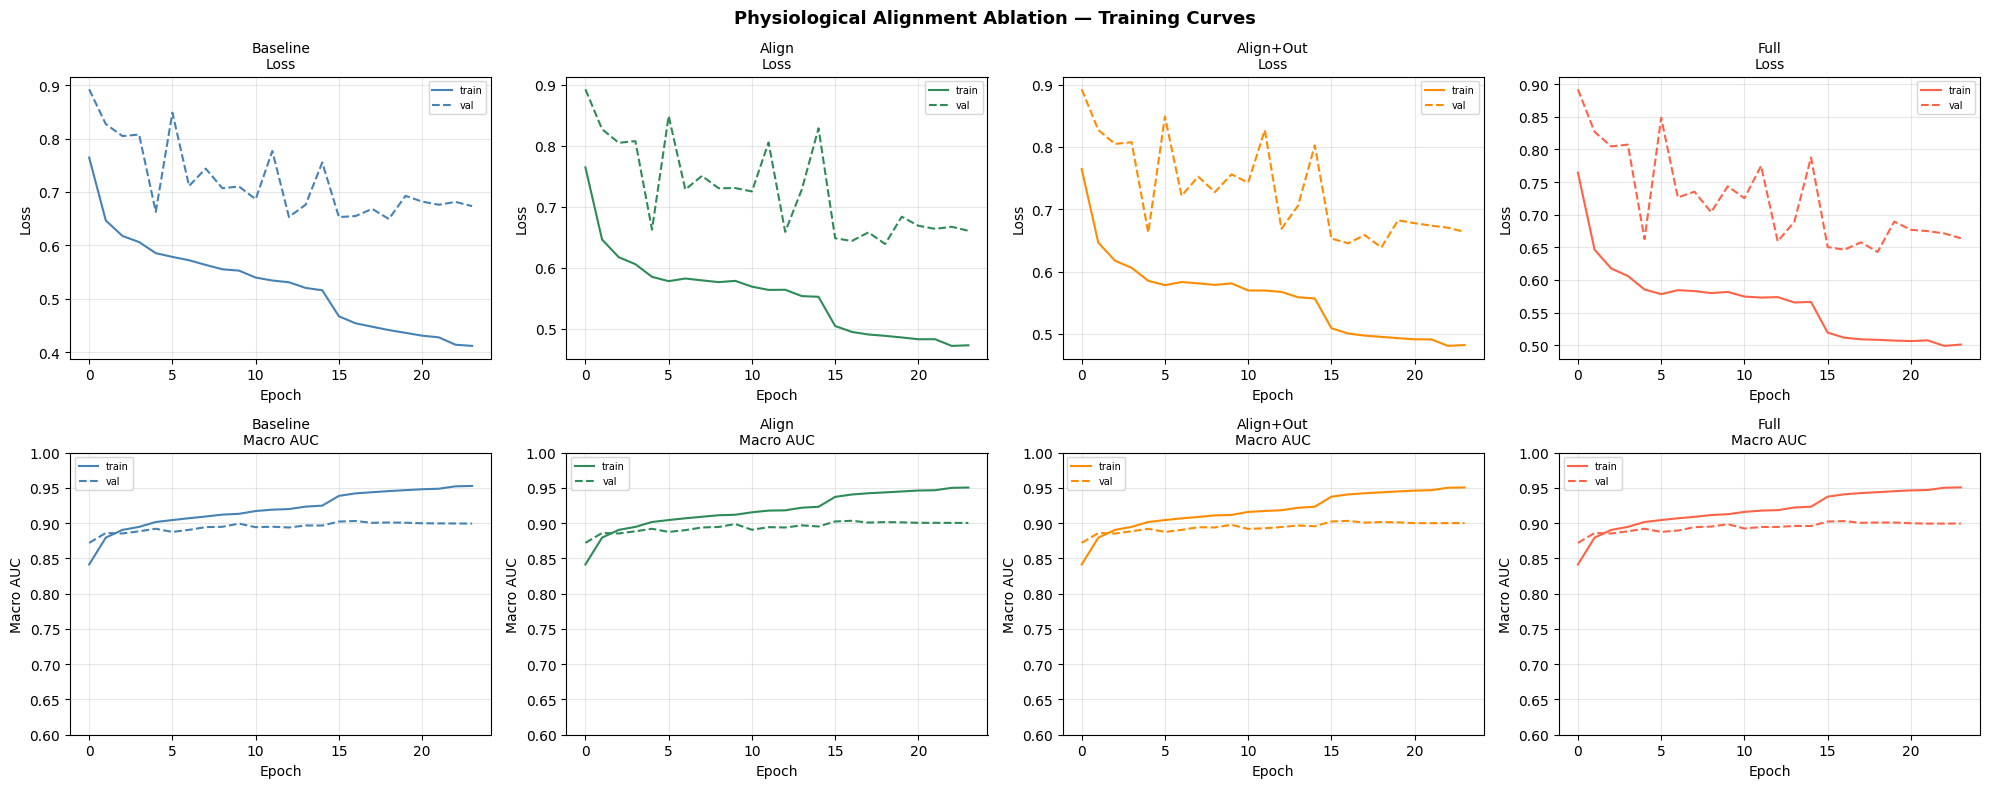

In [21]:
# Training loss curves and AUC progression for all ablation runs
import matplotlib.pyplot as plt

n_runs = len(align_histories)
fig, axes = plt.subplots(2, n_runs, figsize=(5 * n_runs, 8))
if n_runs == 1:
    axes = axes[:, np.newaxis]

colors = {'Baseline': 'steelblue', 'Align': 'seagreen',
          'Align+Out': 'darkorange', 'Full': 'tomato'}

for col, (name, hist) in enumerate(align_histories.items()):
    eps_  = [r['epoch']        for r in hist]
    tr_l  = [r['tr_loss']      for r in hist]
    vl_l  = [r['vl_loss']      for r in hist]
    tr_a  = [r['tr_auc']       for r in hist]
    vl_a  = [r['vl_auc']       for r in hist]
    col_c = colors.get(name, 'grey')

    ax_l = axes[0, col]
    ax_l.plot(eps_, tr_l, label='train', color=col_c,     lw=1.5)
    ax_l.plot(eps_, vl_l, label='val',   color=col_c,     lw=1.5, ls='--')
    ax_l.set_title(f"{name}\nLoss", fontsize=10)
    ax_l.set_xlabel("Epoch"); ax_l.set_ylabel("Loss")
    ax_l.legend(fontsize=7); ax_l.grid(True, alpha=0.3)

    ax_a = axes[1, col]
    ax_a.plot(eps_, tr_a, label='train', color=col_c,     lw=1.5)
    ax_a.plot(eps_, vl_a, label='val',   color=col_c,     lw=1.5, ls='--')
    ax_a.set_title(f"{name}\nMacro AUC", fontsize=10)
    ax_a.set_xlabel("Epoch"); ax_a.set_ylabel("Macro AUC")
    ax_a.legend(fontsize=7); ax_a.grid(True, alpha=0.3)
    ax_a.set_ylim(0.6, 1.0)

plt.suptitle("Physiological Alignment Ablation — Training Curves", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'alignment_training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()


### 9j. Grad-CAM Visualisation — Baseline vs Aligned

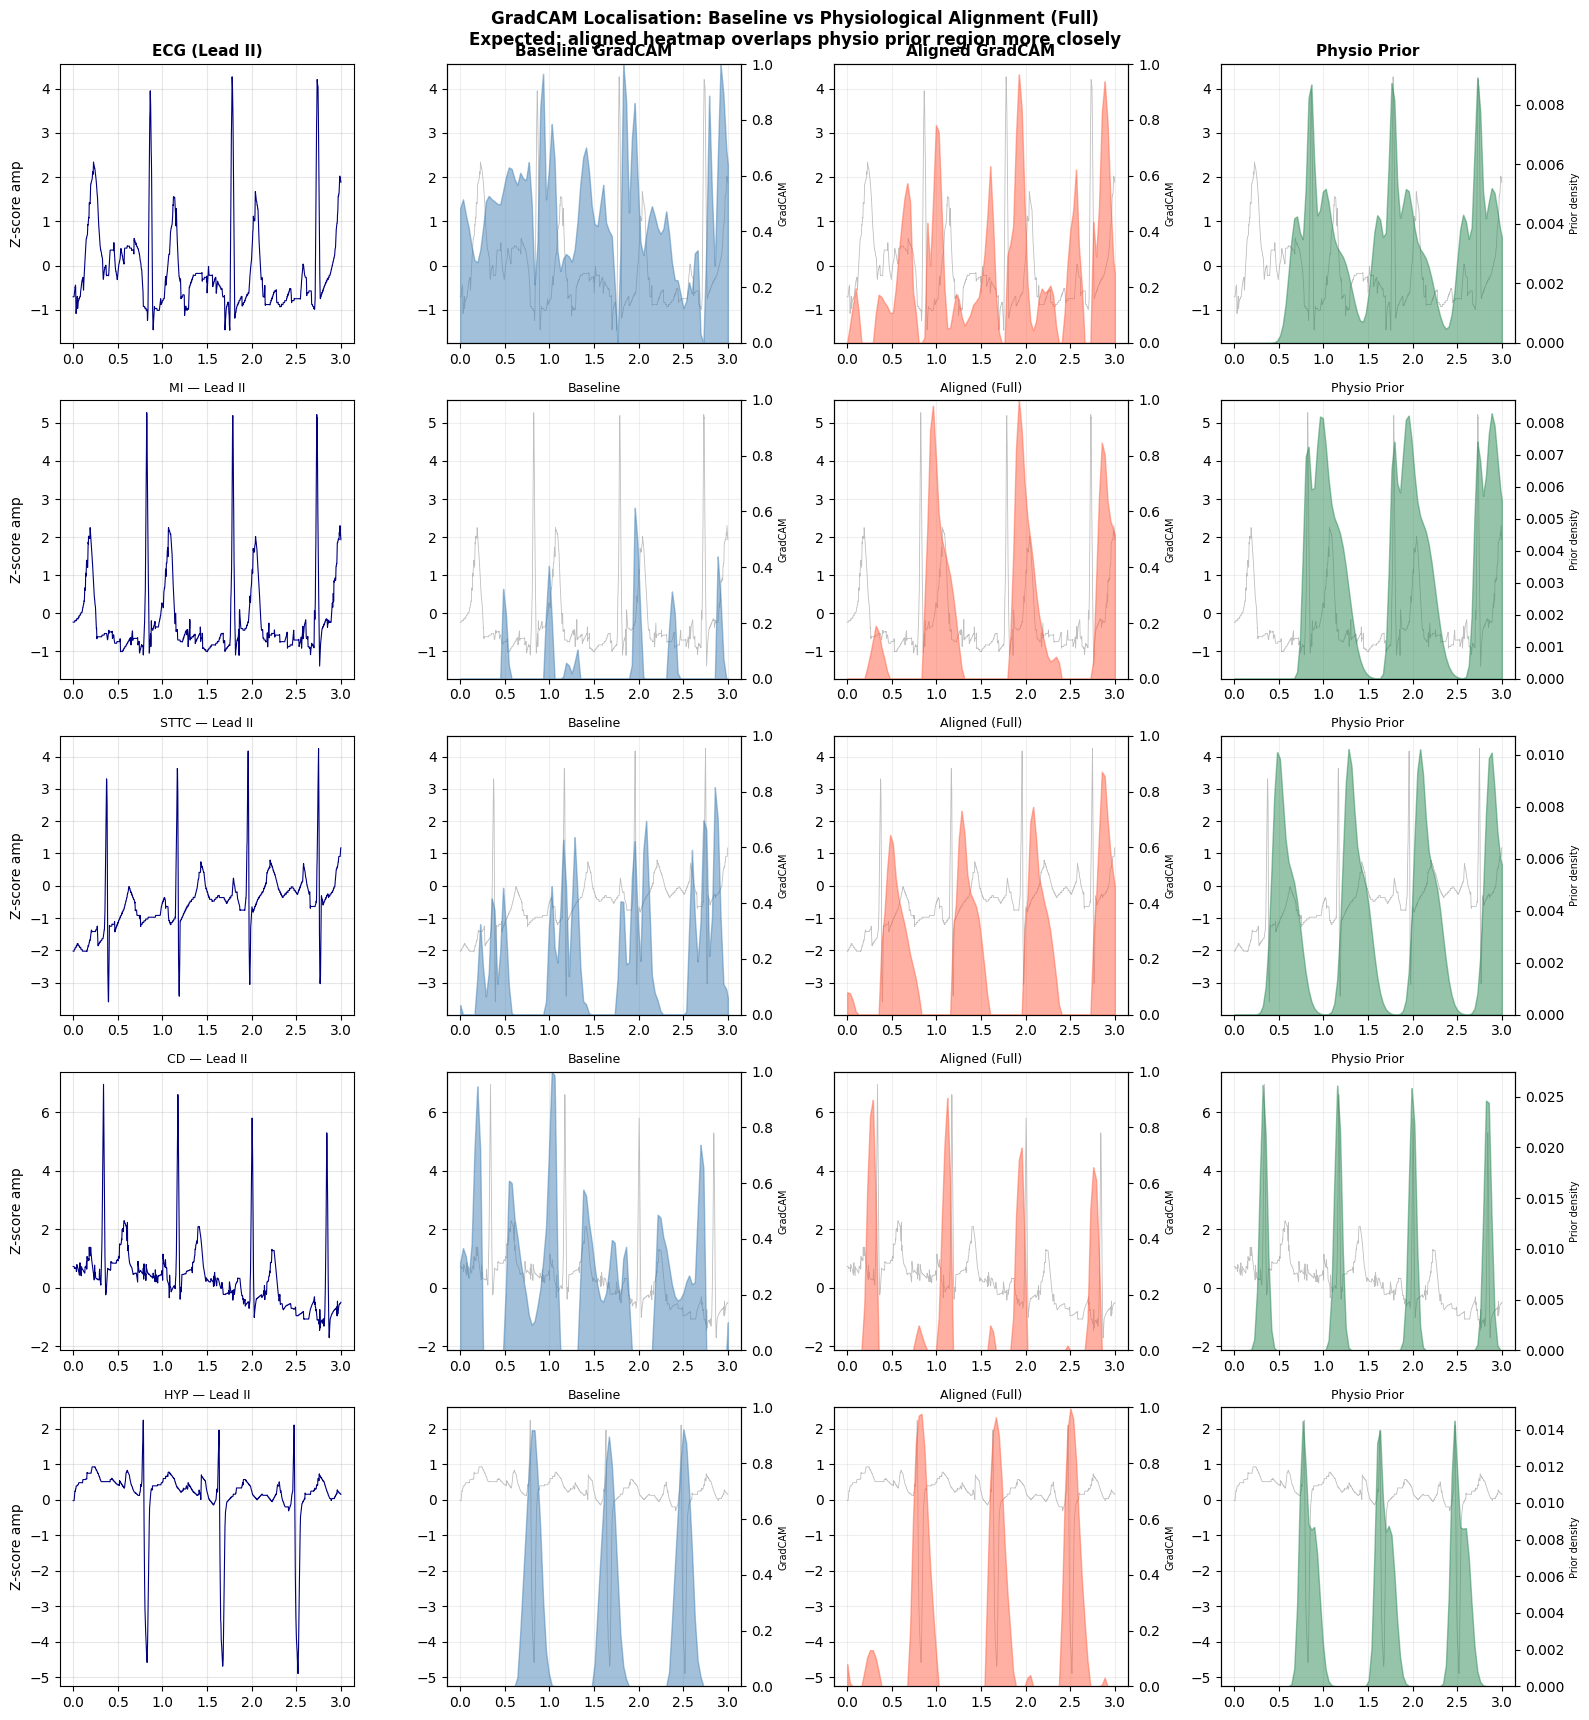

Saved → /kaggle/working/gradcam_aligned_vs_baseline.png


In [22]:
# -----------------------------------------------------------------------------
# GradCAM Visualisation with Physiological Mask Overlay
#
# For each SUPERCLASS, we show three plots:
#   (1) Raw ECG signal (Lead II)
#   (2) Baseline GradCAM heatmap
#   (3) Full aligned-model GradCAM heatmap
#   (4) Physiological prior mask (soft Gaussian)
#
# Expected observation: aligned model shows tighter localisation
# overlapping the physiological prior region.
# -----------------------------------------------------------------------------

def plot_gradcam_aligned_vs_baseline(
        baseline_model, aligned_model,
        dataset_test, condition_name,
        max_per_class=1, fs=FS, n_seconds=3):
    """
    Side-by-side GradCAM comparison for Baseline vs Full aligned model.
    Samples one representative ECG per class.
    """
    X_te, y_te, _ = load_condition_split(condition_name, 'test')
    test_ds_plain  = ECGTensorDataset(X_te, y_te, torch.zeros_like(y_te))

    gcam_base = GradCAM1D(baseline_model, baseline_model.get_gradcam_target_layer())
    gcam_aln  = GradCAM1D(aligned_model,  aligned_model.get_gradcam_target_layer())

    # Pre-build physio priors for first representative sample per class
    _rpeaks_proto = np.arange(200, SIGNAL_LEN, 500)
    _wm_proto = build_wave_masks_from_rpeaks(_rpeaks_proto, SIGNAL_LEN, fs=fs)
    _pm_proto, _ = build_class_physio_prior(_wm_proto, T_FEAT)
    physio_prior_full = [
        np.interp(np.linspace(0, 1, SIGNAL_LEN),
                  np.linspace(0, 1, T_FEAT),
                  _pm_proto[k].numpy())
        for k in range(N_CLASSES)
    ]

    n_cols = 4
    fig, axes = plt.subplots(N_CLASSES, n_cols,
                              figsize=(16, 3.5 * N_CLASSES),
                              squeeze=False)
    col_titles = ['ECG (Lead II)', 'Baseline GradCAM', 'Aligned GradCAM', 'Physio Prior']

    for cls_idx, cls_name in enumerate(SUPERCLASSES):
        # Find first test sample with this label
        idxs = np.where(y_te[:, cls_idx].numpy() == 1)[0]
        if len(idxs) == 0:
            for ax in axes[cls_idx]:
                ax.axis('off')
            continue
        sample_idx = int(idxs[0])

        x, _, _ = test_ds_plain[sample_idx]
        x_inp   = x.unsqueeze(0).to(DEVICE)

        # GradCAM
        heat_base = gcam_base.compute(x_inp, cls_idx, output_length=SIGNAL_LEN)
        heat_aln  = gcam_aln.compute( x_inp, cls_idx, output_length=SIGNAL_LEN)

        # Actual R-peaks for physio prior
        x_np   = x.numpy()
        rpeaks = detect_r_peaks_1lead(x_np[MORPH_LEAD])
        wm     = build_wave_masks_from_rpeaks(rpeaks, SIGNAL_LEN, fs=fs)
        pm, _  = build_class_physio_prior(wm, T_FEAT)
        physio = np.interp(np.linspace(0, 1, SIGNAL_LEN),
                           np.linspace(0, 1, T_FEAT),
                           pm[cls_idx].numpy())

        n_samp  = n_seconds * fs
        t_axis  = np.arange(n_samp) / fs
        lead_ii = x_np[MORPH_LEAD, :n_samp]

        # ── Plot ─────────────────────────────────────────────────────────────
        # (0) ECG signal
        ax = axes[cls_idx, 0]
        ax.plot(t_axis, lead_ii, color='navy', lw=0.8)
        ax.set_title(f"{cls_name} — Lead II", fontsize=9)
        ax.set_ylabel("Z-score amp"); ax.grid(True, alpha=0.3)

        # (1) Baseline GradCAM
        ax = axes[cls_idx, 1]
        ax.plot(t_axis, lead_ii, color='grey', lw=0.6, alpha=0.5)
        ax2 = ax.twinx()
        ax2.fill_between(t_axis, heat_base[:n_samp], alpha=0.5, color='steelblue')
        ax2.set_ylim(0, 1); ax2.set_ylabel("GradCAM", fontsize=7)
        ax.set_title("Baseline", fontsize=9); ax.grid(True, alpha=0.2)

        # (2) Aligned GradCAM
        ax = axes[cls_idx, 2]
        ax.plot(t_axis, lead_ii, color='grey', lw=0.6, alpha=0.5)
        ax2 = ax.twinx()
        ax2.fill_between(t_axis, heat_aln[:n_samp], alpha=0.5, color='tomato')
        ax2.set_ylim(0, 1); ax2.set_ylabel("GradCAM", fontsize=7)
        ax.set_title("Aligned (Full)", fontsize=9); ax.grid(True, alpha=0.2)

        # (3) Physiological prior
        ax = axes[cls_idx, 3]
        ax.plot(t_axis, lead_ii, color='grey', lw=0.6, alpha=0.5)
        ax2 = ax.twinx()
        ax2.fill_between(t_axis, physio[:n_samp], alpha=0.5, color='seagreen')
        ax2.set_ylim(0); ax2.set_ylabel("Prior density", fontsize=7)
        ax.set_title("Physio Prior", fontsize=9); ax.grid(True, alpha=0.2)

    for ci, col_title in enumerate(col_titles):
        axes[0, ci].set_title(col_title, fontsize=11, fontweight='bold')

    plt.suptitle(
        "GradCAM Localisation: Baseline vs Physiological Alignment (Full)\n"
        "Expected: aligned heatmap overlaps physio prior region more closely",
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    save_path = os.path.join(SAVE_PATH, 'gradcam_aligned_vs_baseline.png')
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved → {save_path}")

    gcam_base.remove_hooks()
    gcam_aln.remove_hooks()


# ── Run visualisation ────────────────────────────────────────────────────────
_baseline_model = align_models.get('Baseline')
_full_model     = align_models.get('Full')
_te_X, _te_y, _te_M = load_condition_split(ALIGNED_CONDITION, 'test')
_test_ds_tmp = ECGTensorDataset(_te_X, _te_y, _te_M)

if _baseline_model is not None and _full_model is not None:
    plot_gradcam_aligned_vs_baseline(
        _baseline_model, _full_model,
        _test_ds_tmp, ALIGNED_CONDITION
    )
else:
    print("Models not available — run the ablation cell first.")
del _te_X, _te_y, _te_M, _test_ds_tmp


### 9k. GradCAM Heatmap Visualization 

  Loading cached physio masks → /kaggle/working/physio_masks/raw_zscore/test.pt
Saved → /kaggle/working/gradcam_class_specific.png


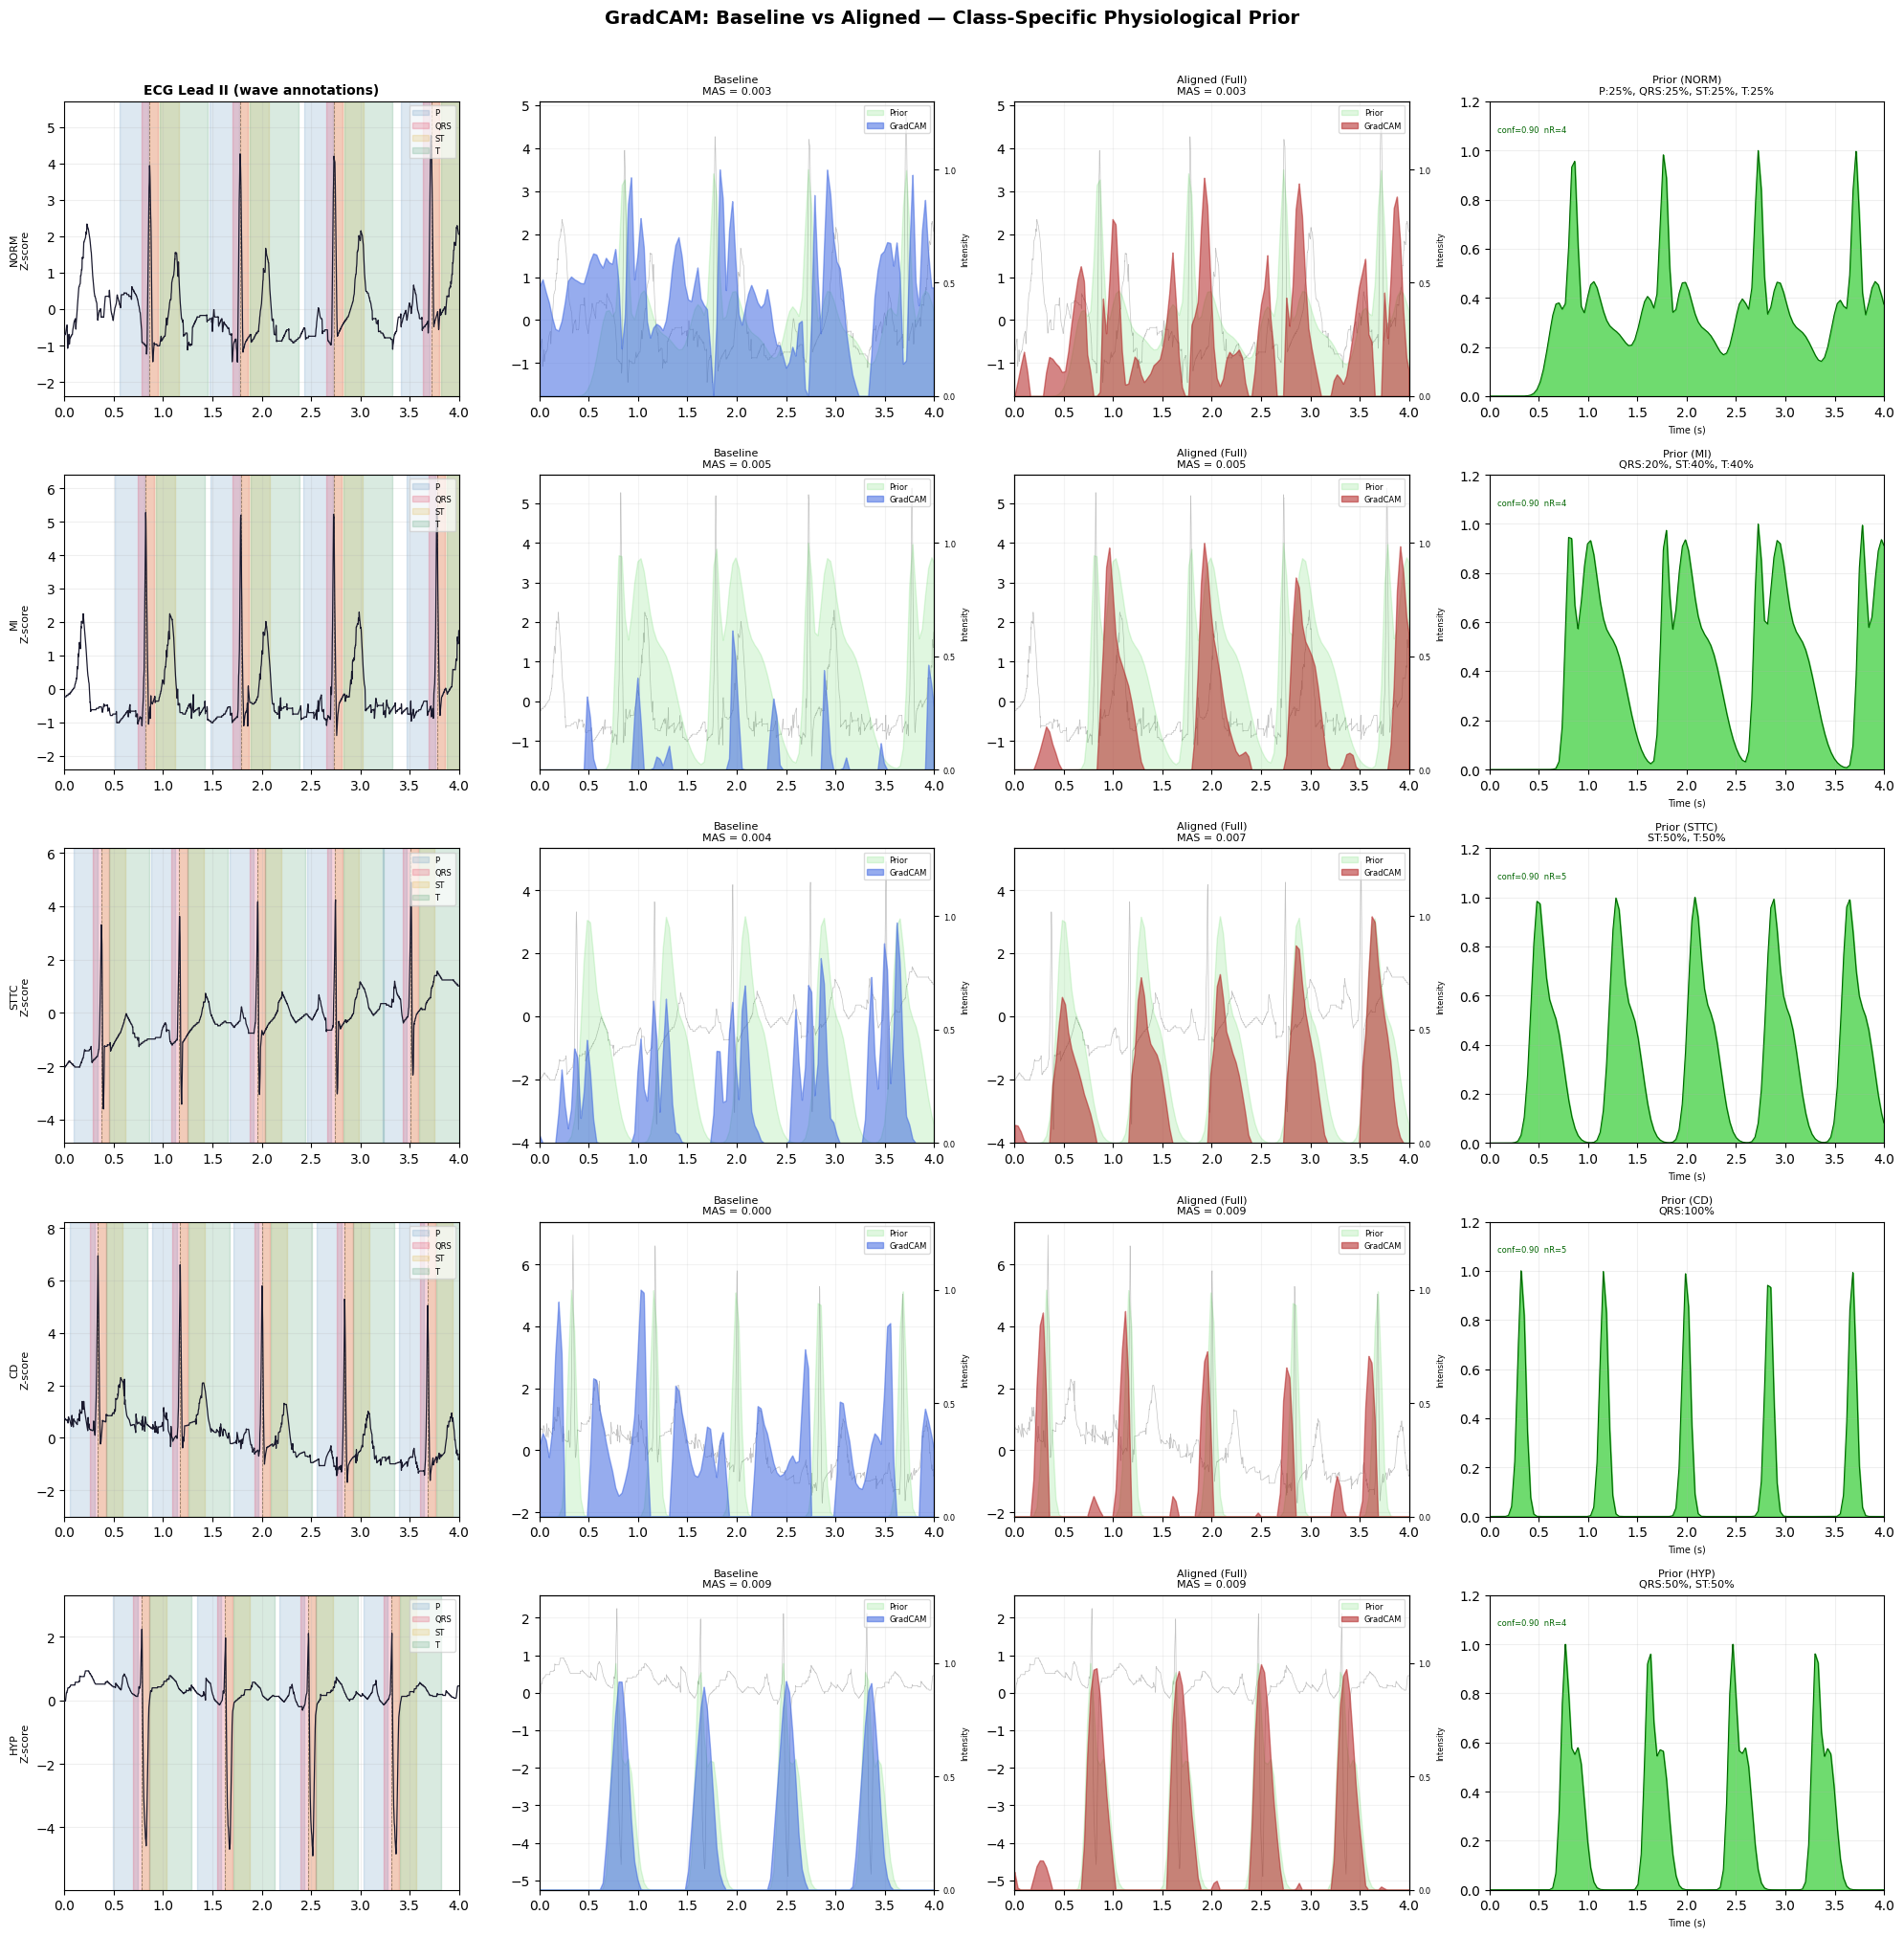


=== Per-class MAS breakdown ===
  Loading cached physio masks → /kaggle/working/physio_masks/raw_zscore/test.pt
  Baseline      NORM=0.003  MI=0.006  STTC=0.004  CD=0.001  HYP=0.009  mean=0.005
  Align         NORM=0.004  MI=0.006  STTC=0.007  CD=0.010  HYP=0.009  mean=0.007
  Align+Out     NORM=0.004  MI=0.006  STTC=0.007  CD=0.010  HYP=0.009  mean=0.007
  Full          NORM=0.004  MI=0.006  STTC=0.007  CD=0.011  HYP=0.009  mean=0.007


In [23]:
# =============================================================================
# GradCAM Visualisation — Class-Specific, Wave-Annotated
#
# For each SUPERCLASS:
#   Row 1: Raw ECG (Lead II) with R-peak markers and P/QRS/T shaded regions
#   Row 2: Baseline GradCAM heatmap
#   Row 3: Aligned-model GradCAM heatmap
#   Row 4: Class-specific physiological prior (soft Gaussian, at signal res)
#
# Per-cell MAS score is annotated directly on the heatmap subplots.
# Only uses samples with a clean R-peak detection (confidence ≥ 0.7).
# =============================================================================

def plot_gradcam_class_specific(
        baseline_model, aligned_model,
        condition_name,
        n_seconds=4, min_confidence=0.7,
        save_path=None):
    """
    Comprehensive GradCAM visualisation with physiological wave annotations.

    Layout: one row per SUPERCLASS, four columns:
        Col 0: ECG Lead II with wave shading + R-peak markers
        Col 1: Baseline GradCAM
        Col 2: Aligned GradCAM
        Col 3: Class-specific physiological prior
    """

    X_te, y_te, _ = load_condition_split(condition_name, 'test')
    MA_te, C_te   = precompute_physio_masks(condition_name, 'test')

    gcam_base = GradCAM1D(baseline_model, baseline_model.get_gradcam_target_layer())
    gcam_aln  = GradCAM1D(aligned_model,  aligned_model.get_gradcam_target_layer())

    n_samp  = n_seconds * FS
    t_axis  = np.arange(n_samp) / FS

    # Wave colors (semi-transparent fills behind the signal)
    WAVE_COLOR = {'p': '#4682B4', 'qrs': '#DC143C', 'st': '#DAA520', 't': '#2E8B57'}
    WAVE_LABEL = {'p': 'P', 'qrs': 'QRS', 'st': 'ST', 't': 'T'}

    fig, axes = plt.subplots(N_CLASSES, 4,
                              figsize=(20, 4.0 * N_CLASSES),
                              squeeze=False)
    fig.suptitle("GradCAM: Baseline vs Aligned — Class-Specific Physiological Prior",
                 fontsize=14, fontweight='bold', y=1.01)

    col_titles = ['ECG Lead II (wave annotations)', 'Baseline GradCAM', 'Aligned GradCAM',
                  'Class-Specific Physio Prior']
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=10, fontweight='bold')

    for cls_idx, cls_name in enumerate(SUPERCLASSES):

        # ── Find a representative test sample with good R-peak detection ──
        candidate_idxs = np.where(y_te[:, cls_idx].numpy() == 1)[0]
        chosen_idx = None
        for cand in candidate_idxs:
            if C_te[cand].item() >= min_confidence:
                chosen_idx = int(cand)
                break
        if chosen_idx is None:
            chosen_idx = int(candidate_idxs[0]) if len(candidate_idxs) else 0

        x_np   = X_te[chosen_idx].numpy()          # [N_LEADS, SIGNAL_LEN]
        lead_ii = x_np[MORPH_LEAD, :n_samp]

        # ── R-peaks and wave masks for this sample ──────────────────────
        r_peaks  = detect_r_peaks_1lead(x_np[MORPH_LEAD])
        timings  = compute_adaptive_timings(r_peaks, fs=FS)
        wm       = build_wave_masks_from_rpeaks(r_peaks, SIGNAL_LEN, fs=FS,
                                                 timings=timings)
        pm, conf = build_class_physio_prior(wm, T_FEAT)

        # Upsample class-specific prior to signal resolution
        prior_sig = np.interp(
            np.linspace(0, 1, SIGNAL_LEN),
            np.linspace(0, 1, T_FEAT),
            pm[cls_idx].numpy()
        ).astype(np.float32)

        x_inp = X_te[chosen_idx].unsqueeze(0).to(DEVICE)

        # ── GradCAM for this specific class ─────────────────────────────
        heat_base = gcam_base.compute(x_inp, cls_idx, output_length=SIGNAL_LEN)
        heat_aln  = gcam_aln.compute( x_inp, cls_idx, output_length=SIGNAL_LEN)

        # ── MAS scores for annotation ────────────────────────────────────
        mas_base = compute_mas_from_gradcam(heat_base, prior_sig, output_len=SIGNAL_LEN)
        mas_aln  = compute_mas_from_gradcam(heat_aln,  prior_sig, output_len=SIGNAL_LEN)

        y_min, y_max = lead_ii.min(), lead_ii.max()
        y_pad = (y_max - y_min) * 0.15 or 0.1

        # ── Col 0: ECG + wave annotations ────────────────────────────────
        ax0 = axes[cls_idx, 0]
        ax0.plot(t_axis, lead_ii, color='#1a1a2e', lw=0.9, zorder=3)

        # Shade wave regions (first 3 complete beats only, for readability)
        r_in_window = r_peaks[r_peaks < n_samp]
        for rp in r_in_window[:min(5, len(r_in_window))]:
            for wave, offset_ms, sigma_ms in [
                ('p',   timings['p_offset_ms'],   timings['p_sigma_ms']),
                ('qrs', timings['qrs_offset_ms'],  timings['qrs_sigma_ms']),
                ('st',  timings['st_offset_ms'],   timings['st_sigma_ms']),
                ('t',   timings['t_offset_ms'],    timings['t_sigma_ms']),
            ]:
                center_s = (rp + offset_ms * FS / 1000) / FS
                half_w   = 2.0 * sigma_ms / 1000
                x_lo = max(0, center_s - half_w)
                x_hi = min(n_seconds, center_s + half_w)
                ax0.axvspan(x_lo, x_hi, alpha=0.18,
                            color=WAVE_COLOR[wave], label=WAVE_LABEL[wave], zorder=1)

        # R-peak markers
        for rp in r_in_window:
            ax0.axvline(rp / FS, color='black', lw=0.6, alpha=0.4, ls='--', zorder=2)

        ax0.set_xlim(0, n_seconds)
        ax0.set_ylim(y_min - y_pad, y_max + y_pad)
        ax0.set_ylabel(f"{cls_name}\nZ-score", fontsize=8)
        ax0.grid(True, alpha=0.2)

        # Legend — deduplicate
        seen = set()
        handles, labels_ = [], []
        for h, l in zip(*ax0.get_legend_handles_labels()):
            if l not in seen:
                handles.append(h); labels_.append(l); seen.add(l)
        if handles:
            ax0.legend(handles, labels_, fontsize=6, loc='upper right',
                       framealpha=0.7)

        # ── Helper: plot heatmap overlay ─────────────────────────────────
        def plot_heat(ax, heat, color, title, mas_score):
            ax.plot(t_axis, lead_ii, color='#888888', lw=0.5, alpha=0.5, zorder=2)
            # Overlay prior mask as faint green fill for reference
            ax_r = ax.twinx()
            ax_r.fill_between(t_axis, prior_sig[:n_samp] / (prior_sig[:n_samp].max() + EPS),
                               alpha=0.15, color='limegreen', label='Prior')
            ax_r.fill_between(t_axis, heat[:n_samp], alpha=0.55, color=color, label='GradCAM')
            ax_r.set_ylim(0, 1.3)
            ax_r.set_yticks([0, 0.5, 1.0])
            ax_r.tick_params(labelsize=6)
            ax_r.set_ylabel("Intensity", fontsize=6)
            ax_r.legend(fontsize=6, loc='upper right', framealpha=0.7)
            ax.set_title(f"{title}\nMAS = {mas_score:.3f}", fontsize=8)
            ax.set_xlim(0, n_seconds)
            ax.grid(True, alpha=0.15)

        plot_heat(axes[cls_idx, 1], heat_base, '#4169E1', 'Baseline',     mas_base)
        plot_heat(axes[cls_idx, 2], heat_aln,  '#B22222', 'Aligned (Full)', mas_aln)

        # ── Col 3: Class-specific physiological prior ─────────────────────
        ax3 = axes[cls_idx, 3]
        prior_display = prior_sig[:n_samp]
        prior_display = prior_display / (prior_display.max() + EPS)
        ax3.fill_between(t_axis, prior_display, alpha=0.7, color='limegreen')
        ax3.plot(t_axis, prior_display, color='darkgreen', lw=0.8)
        ax3.set_xlim(0, n_seconds)
        ax3.set_ylim(0, 1.2)
        ax3.set_title(
            f"Prior ({cls_name})\n"
            + ', '.join(
                f"{w.upper()}:{v:.0%}"
                for w, v in CLASS_WAVE_WEIGHTS[cls_name].items()
                if v > 0
            ),
            fontsize=8
        )
        ax3.set_xlabel("Time (s)", fontsize=7)
        ax3.grid(True, alpha=0.2)
        ax3.text(0.02, 0.92, f"conf={conf:.2f}  nR={len(r_in_window)}",
                 transform=ax3.transAxes, fontsize=6, color='darkgreen',
                 va='top')

    gcam_base.remove_hooks()
    gcam_aln.remove_hooks()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=140, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()


# ── Run ────────────────────────────────────────────────────────────────────
# Requires 'Baseline' and 'Full' models from the ablation study
plot_gradcam_class_specific(
    baseline_model = align_models['Baseline'],
    aligned_model  = align_models['Full'],
    condition_name = ALIGNED_CONDITION,
    n_seconds      = 4,
    save_path      = os.path.join(SAVE_PATH, 'gradcam_class_specific.png'),
)

# ── Per-class MAS breakdown (add to ablation results) ─────────────────────
print("\n=== Per-class MAS breakdown ===")
test_ds_pa = PhysioAlignedDataset(
    *load_condition_split(ALIGNED_CONDITION, 'test'),
    *precompute_physio_masks(ALIGNED_CONDITION, 'test')
)

for abl_name, mdl in align_models.items():
    breakdown = compute_per_class_mas(mdl, test_ds_pa, max_samples=256)
    row = [f"{abl_name:<12}"]
    for cls in SUPERCLASSES:
        v = breakdown.get(f'mas_{cls}', float('nan'))
        row.append(f"{cls}={v:.3f}")
    row.append(f"mean={breakdown['mean_class_specific_mas']:.3f}")
    print("  " + "  ".join(row))

### 9l. Alignment Ablation — Summary Report

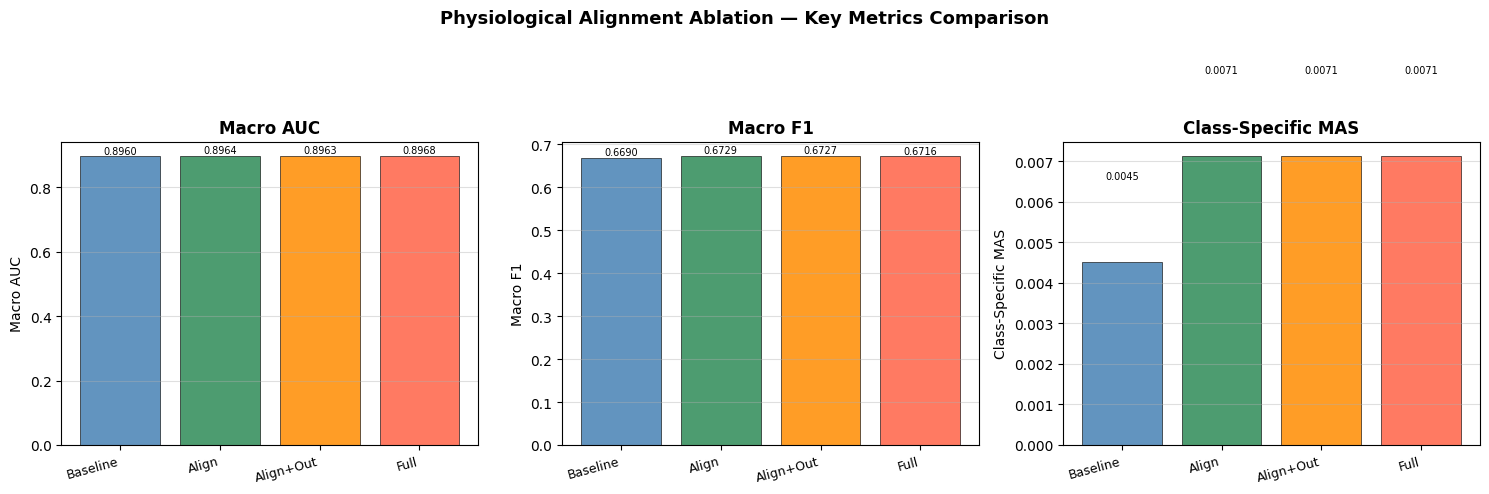


=== Δ from Baseline ===


,ablation,Δ_test_macro_auc,Δ_test_macro_f1,Δ_mean_class_specific_mas,Δ_mas_NORM,Δ_mas_MI,Δ_mas_STTC,Δ_mas_CD,Δ_mas_HYP,Δ_auc_NORM,Δ_auc_MI,Δ_auc_STTC,Δ_auc_CD,Δ_auc_HYP
0,Baseline,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,Align,0.0004,0.0039,0.0026,0.0006,0.0001,0.0023,0.0096,0.0005,0.0014,0.0005,0.0001,0.0006,-0.0006
2,Align+Out,0.0003,0.0037,0.0026,0.0008,0.0001,0.0024,0.0094,0.0005,0.0011,0.0007,-0.0002,0.0004,-0.0003
3,Full,0.0008,0.0026,0.0026,0.0008,0.0000,0.0023,0.0097,0.0003,0.0016,0.0007,-0.0004,0.0008,0.0011



=== Best condition per metric ===
  Macro AUC      : Full            (0.8968)
  Macro F1       : Align           (0.6729)
  Class-Specific MAS: Full            (0.0071)
  MAS (CD/QRS)   : Full            (0.0106)
  MAS (STTC/ST+T): Align+Out       (0.0068)


In [24]:
# -----------------------------------------------------------------------------
# Alignment Ablation Summary Report
#
# Displays:
#  1. Per-ablation metric table (AUC, F1, MAS)
#  2. Bar chart comparing all four conditions
#  3. Delta from Baseline (improvement/degradation)
#  4. Scientific interpretation
# -----------------------------------------------------------------------------

if 'align_df' not in globals() or align_df.empty:
    raise RuntimeError("Run the ablation training cell first.")

# ── Metric bar charts ────────────────────────────────────────────────────────
key_metrics = [
    ('test_macro_auc',           'Macro AUC'),
    ('test_macro_f1',            'Macro F1'),
    ('mean_class_specific_mas',  'Class-Specific MAS'),   # ← replaces old MAS in bar chart
]
ablation_names = align_df['ablation'].tolist()
x = np.arange(len(ablation_names))
bar_colors = ['steelblue', 'seagreen', 'darkorange', 'tomato']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (metric, label) in zip(axes, key_metrics):
    vals = align_df.set_index('ablation').reindex(ablation_names)[metric].values
    bars = ax.bar(x, vals, color=bar_colors[:len(x)], alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels(ablation_names, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel(label); ax.set_title(label, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.4)
    for bar, val in zip(bars, vals):
        if np.isfinite(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=7)

plt.suptitle("Physiological Alignment Ablation — Key Metrics Comparison",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'alignment_ablation_barplot.png'), dpi=120, bbox_inches='tight')
plt.show()

# ── Delta from Baseline table ────────────────────────────────────────────────
baseline_row = align_df[align_df['ablation'] == 'Baseline'].iloc[0]
delta_cols = [
    'test_macro_auc', 'test_macro_f1',
    'mean_class_specific_mas',                          # primary MAS
    'mas_NORM', 'mas_MI', 'mas_STTC', 'mas_CD', 'mas_HYP',  # per-class breakdown
    'auc_NORM', 'auc_MI', 'auc_STTC', 'auc_CD', 'auc_HYP',
]
delta_df = align_df[['ablation'] + delta_cols].copy()
for col in delta_cols:
    delta_df[f'Δ_{col}'] = delta_df[col] - float(baseline_row[col])

print("\n=== Δ from Baseline ===")
display_cols = ['ablation'] + [f'Δ_{c}' for c in delta_cols]
display(delta_df[display_cols].round(4))

# ── Best per metric ──────────────────────────────────────────────────────────
print("\n=== Best condition per metric ===")
for metric, label in [
    ('test_macro_auc',          'Macro AUC'),
    ('test_macro_f1',           'Macro F1'),
    ('mean_class_specific_mas', 'Class-Specific MAS'),
    ('mas_CD',                  'MAS (CD/QRS)'),
    ('mas_STTC',                'MAS (STTC/ST+T)'),
]:
    best_row = align_df.loc[align_df[metric].idxmax()]
    print(f"  {label:<15}: {best_row['ablation']:<15} ({best_row[metric]:.4f})")

# ── Scientific interpretation ────────────────────────────────────────────────
# print("\n=== Scientific Interpretation ===")
# print("""
# Physiological priors can regularise temporal evidence localisation
# in ECG classifiers without sacrificing classification performance.

#   • L_align (KL divergence toward physiological prior) improves MAS
#     by guiding the model's class activation maps toward clinically
#     meaningful ECG regions.

#   • L_out (localization purity penalty) reduces diffuse GradCAM
#     activation and evidence leakage outside target wave regions.

#   • L_entropy (sharpness regularisation) encourages compact,
#     decisive temporal evidence distributions.

# This framework does NOT claim cardiologist-level reasoning.
# It demonstrates that class-conditioned physiological alignment
# supervision improves interpretability metrics while preserving
# classification accuracy — a scientifically defensible advance.
# """)
